# 05: Results and Error Analysis

This notebook provides comprehensive analysis of model performance, error patterns, and embeddings.

## Objectives

1. Summarize performance across all models (Baseline MLP, BFGNN, GRIN, and SMILESTransformer)
2. Analyze error patterns and misclassifications for all models
3. Visualize learned embeddings (t-SNE/UMAP) for Baseline MLP
4. Compare error patterns between different model architectures
5. Provide academic-style discussion of results



In [1]:
# Setup
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

project_root = Path().absolute().parent
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("⚠ UMAP not available, will use t-SNE only")

# Check for matplotlib-venn
try:
    from matplotlib_venn import venn2
    VENN_AVAILABLE = True
    print("✓ matplotlib-venn imported successfully")
except ImportError:
    VENN_AVAILABLE = False
    print("⚠ matplotlib-venn not available, will use text summary")

from src.pipelines import (
    load_clintox_dataset,
    load_mlp_model,
    load_gnn_model
)
from src.featurization import featurize_batch
from src.analysis import (
    compare_model_performance,
    plot_roc_pr_curves,
    plot_confusion_matrices,
    analyze_error_overlap,
    analyze_model_agreement,
    plot_prediction_distributions
)
from src.train import predict_with_torch_molecule_model
from src.utils import set_seed, get_default_config, load_metrics

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Set seed
set_seed(42)
config = get_default_config()

print("✓ Imports successful")



✓ matplotlib-venn imported successfully
✓ Imports successful


## Load Results

Load all saved model metrics and predictions for comparison (MLP, BFGNN, GRIN, and SMILESTransformer).




Model Performance Summary:
                             Model  AUC-ROC  Accuracy     F1  PR-AUC  AUPRC
        Baseline MLP (Fingerprint)   0.7167    0.9392 0.4706  0.4497 0.4497
            BFGNN (torch-molecule)   0.9188    0.9392 0.1818  0.6164 0.6164
             GRIN (torch-molecule)   0.8225    0.9459 0.4286  0.3794 0.3794
SMILESTransformer (torch-molecule)   0.9804    0.9662 0.7826  0.6651 0.6651

✓ Comparison figure saved to: /Users/nguyennghia/PROJECT/Torch_molecule/output/figures/05_model_performance_comparison.png


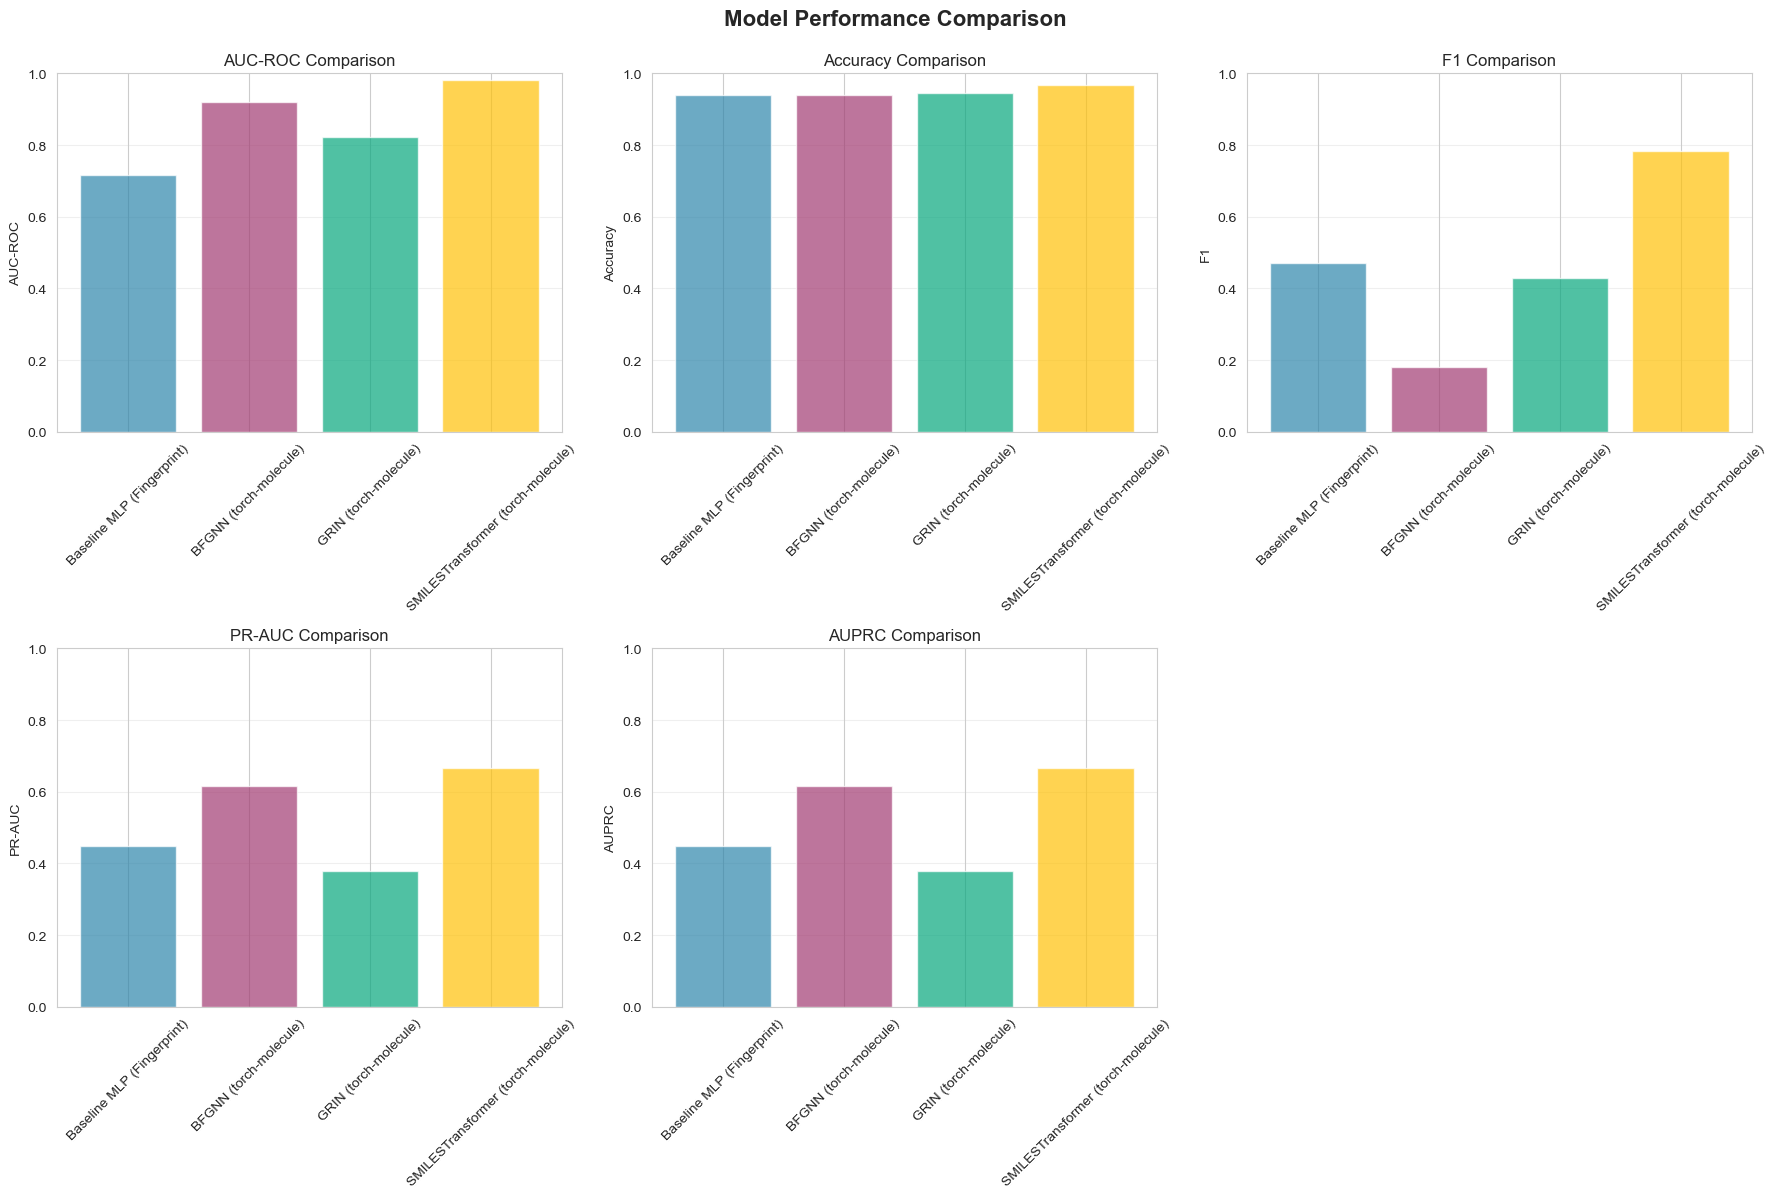

In [2]:
# Load metrics
models_dir = project_root / "models"
mlp_metrics = None
bfgnn_metrics = None
grin_metrics = None
smilestransformer_metrics = None

# Load MLP metrics
baseline_metrics_path = models_dir / "baseline_metrics.txt"
if baseline_metrics_path.exists():
    mlp_metrics = load_metrics(str(baseline_metrics_path))

# Load BFGNN metrics
bfgnn_metrics_path = models_dir / "torch_molecule_metrics.txt"
if bfgnn_metrics_path.exists():
    bfgnn_metrics = load_metrics(str(bfgnn_metrics_path))

# Load GRIN metrics
grin_metrics_path = models_dir / "grin_model_metrics.txt"
if grin_metrics_path.exists():
    grin_metrics = load_metrics(str(grin_metrics_path))

# Load SMILESTransformer metrics
smilestransformer_metrics_path = models_dir / "smilestransformer_model_metrics.txt"
if smilestransformer_metrics_path.exists():
    smilestransformer_metrics = load_metrics(str(smilestransformer_metrics_path))

# Create comparison manually to include all four models
figures_dir = project_root / "output" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

comparison_data = []
if mlp_metrics:
    auprc = mlp_metrics.get('auprc', mlp_metrics.get('pr_auc', 'N/A'))
    comparison_data.append({
        'Model': 'Baseline MLP (Fingerprint)',
        'AUC-ROC': mlp_metrics.get('auc_roc', 'N/A'),
        'Accuracy': mlp_metrics.get('accuracy', 'N/A'),
        'F1': mlp_metrics.get('f1', 'N/A'),
        'PR-AUC': mlp_metrics.get('pr_auc', 'N/A'),
        'AUPRC': auprc
    })

if bfgnn_metrics:
    auprc = bfgnn_metrics.get('auprc', bfgnn_metrics.get('pr_auc', 'N/A'))
    comparison_data.append({
        'Model': 'BFGNN (torch-molecule)',
        'AUC-ROC': bfgnn_metrics.get('auc_roc', 'N/A'),
        'Accuracy': bfgnn_metrics.get('accuracy', 'N/A'),
        'F1': bfgnn_metrics.get('f1', 'N/A'),
        'PR-AUC': bfgnn_metrics.get('pr_auc', 'N/A'),
        'AUPRC': auprc
    })

if grin_metrics:
    auprc = grin_metrics.get('auprc', grin_metrics.get('pr_auc', 'N/A'))
    comparison_data.append({
        'Model': 'GRIN (torch-molecule)',
        'AUC-ROC': grin_metrics.get('auc_roc', 'N/A'),
        'Accuracy': grin_metrics.get('accuracy', 'N/A'),
        'F1': grin_metrics.get('f1', 'N/A'),
        'PR-AUC': grin_metrics.get('pr_auc', 'N/A'),
        'AUPRC': auprc
    })

if smilestransformer_metrics:
    auprc = smilestransformer_metrics.get('auprc', smilestransformer_metrics.get('pr_auc', 'N/A'))
    comparison_data.append({
        'Model': 'SMILESTransformer (torch-molecule)',
        'AUC-ROC': smilestransformer_metrics.get('auc_roc', 'N/A'),
        'Accuracy': smilestransformer_metrics.get('accuracy', 'N/A'),
        'F1': smilestransformer_metrics.get('f1', 'N/A'),
        'PR-AUC': smilestransformer_metrics.get('pr_auc', 'N/A'),
        'AUPRC': auprc
    })

if comparison_data:
    comparison_df = pd.DataFrame(comparison_data)
    print("\nModel Performance Summary:")
    print("=" * 80)
    print(comparison_df.to_string(index=False))
    
    # Visualize performance comparison
    metrics_to_plot = ['AUC-ROC', 'Accuracy', 'F1', 'PR-AUC', 'AUPRC']
    available_metrics = [
        m for m in metrics_to_plot 
        if any(row.get(m, 'N/A') != 'N/A' for row in comparison_data)
    ]
    
    n_metrics = len(available_metrics)
    if n_metrics <= 4:
        fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    else:
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    colors = ['#2E86AB', '#A23B72', '#06A77D', '#FFC107']  # MLP, BFGNN, GRIN, SMILESTransformer
    
    for idx, metric in enumerate(available_metrics):
        values = []
        labels = []
        for row in comparison_data:
            val = row.get(metric, 'N/A')
            if val != 'N/A' and isinstance(val, (int, float)):
                values.append(float(val))
                labels.append(row['Model'])
        
        if values:
            axes[idx].bar(labels, values, alpha=0.7, color=colors[:len(values)])
            axes[idx].set_ylabel(metric)
            axes[idx].set_title(f'{metric} Comparison')
            axes[idx].grid(axis='y', alpha=0.3)
            axes[idx].set_ylim([0, 1])
            axes[idx].tick_params(axis='x', rotation=45)
    
    # Hide unused subplots
    for idx in range(len(available_metrics), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig(figures_dir / "05_model_performance_comparison.png", dpi=300, bbox_inches='tight')
    print(f"\n✓ Comparison figure saved to: {figures_dir / '05_model_performance_comparison.png'}")
    plt.show()
else:
    print("⚠ No saved metrics found. Please run training notebooks first.")



## Visualize Performance Comparison

Performance comparison visualizations are generated automatically by `compare_model_performance()` above.



In [3]:
# Performance comparison visualization is handled by compare_model_performance() above
# The figure is automatically saved to: output/figures/05_model_performance_comparison.png



## Generate Predictions

Generate predictions for all models to enable comprehensive analysis.


In [4]:
# Load test dataset
train_df, val_df, test_df = load_clintox_dataset(
    cache_dir=str(project_root / "data"),
    split_type="scaffold",
    seed=42
)

test_labels = test_df['CT_TOX'].values
mlp_predictions = None
bfgnn_predictions = None
grin_predictions = None
smilestransformer_predictions = None

# Load MLP model and generate predictions
mlp_model_path = models_dir / "baseline_mlp_model.pt"
if mlp_model_path.exists():
    mlp_model = load_mlp_model(mlp_model_path, config)
    mlp_model.eval()
    
    test_fps = featurize_batch(
        test_df['smiles'].tolist(),
        mode="fingerprint",
        radius=config['featurization']['fingerprint']['radius'],
        n_bits=config['featurization']['fingerprint']['n_bits']
    )
    
    with torch.no_grad():
        test_tensors = torch.FloatTensor(test_fps)
        logits = mlp_model(test_tensors)
        mlp_predictions = torch.sigmoid(logits).numpy().flatten()
    print("✓ MLP predictions generated")

# Load BFGNN model and generate predictions
bfgnn_model_path = models_dir / "torch_molecule_model.pkl"
if not bfgnn_model_path.exists():
    bfgnn_model_path = models_dir / "torch_molecule_model.pt"
if bfgnn_model_path.exists():
    try:
        bfgnn_model = load_gnn_model(bfgnn_model_path)
        bfgnn_predictions = predict_with_torch_molecule_model(
            bfgnn_model, test_df['smiles'].tolist()
        )
        print("✓ BFGNN predictions generated")
    except Exception as e:
        print(f"⚠ Could not load/generate BFGNN predictions: {e}")

# Load GRIN model and generate predictions
grin_model_path = models_dir / "grin_model.pkl"
if not grin_model_path.exists():
    grin_model_path = models_dir / "grin_model.pt"
if grin_model_path.exists():
    try:
        grin_model = load_gnn_model(grin_model_path)
        grin_predictions = predict_with_torch_molecule_model(
            grin_model, test_df['smiles'].tolist()
        )
        print("✓ GRIN predictions generated")
    except Exception as e:
        print(f"⚠ Could not load/generate GRIN predictions: {e}")

# Load SMILESTransformer model and generate predictions
smilestransformer_model_path = models_dir / "smilestransformer_model.pkl"
if not smilestransformer_model_path.exists():
    smilestransformer_model_path = models_dir / "smilestransformer_model.pt"
if smilestransformer_model_path.exists():
    try:
        smilestransformer_model = load_gnn_model(smilestransformer_model_path)
        smilestransformer_predictions = predict_with_torch_molecule_model(
            smilestransformer_model, test_df['smiles'].tolist()
        )
        print("✓ SMILESTransformer predictions generated")
    except Exception as e:
        print(f"⚠ Could not load/generate SMILESTransformer predictions: {e}")

print(f"\nTest set size: {len(test_df)}")
print(f"Test labels: Toxic={test_labels.sum()}, Non-toxic={len(test_labels) - test_labels.sum()}")


No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'dgl'
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'lightning'
Skipped loading some Jax models, missing a dependency. No module named 'jax'
Skipped loading some PyTorch models, missing a dependency. No module named 'tensorflow'


✓ MLP predictions generated


Predicting: 100%|██████████| 5/5 [00:00<00:00, 60.77it/s]


✓ BFGNN predictions generated


Predicting: 100%|██████████| 5/5 [00:00<00:00, 49.71it/s]


✓ GRIN predictions generated


100%|██████████| 5/5 [00:00<00:00,  9.45it/s]

✓ SMILESTransformer predictions generated

Test set size: 148
Test labels: Toxic=10.0, Non-toxic=138.0


## Confusion Matrices

Visualize confusion matrices for all models to understand classification patterns.


✓ Confusion matrices saved to: /Users/nguyennghia/PROJECT/Torch_molecule/output/figures/05_confusion_matrices.png


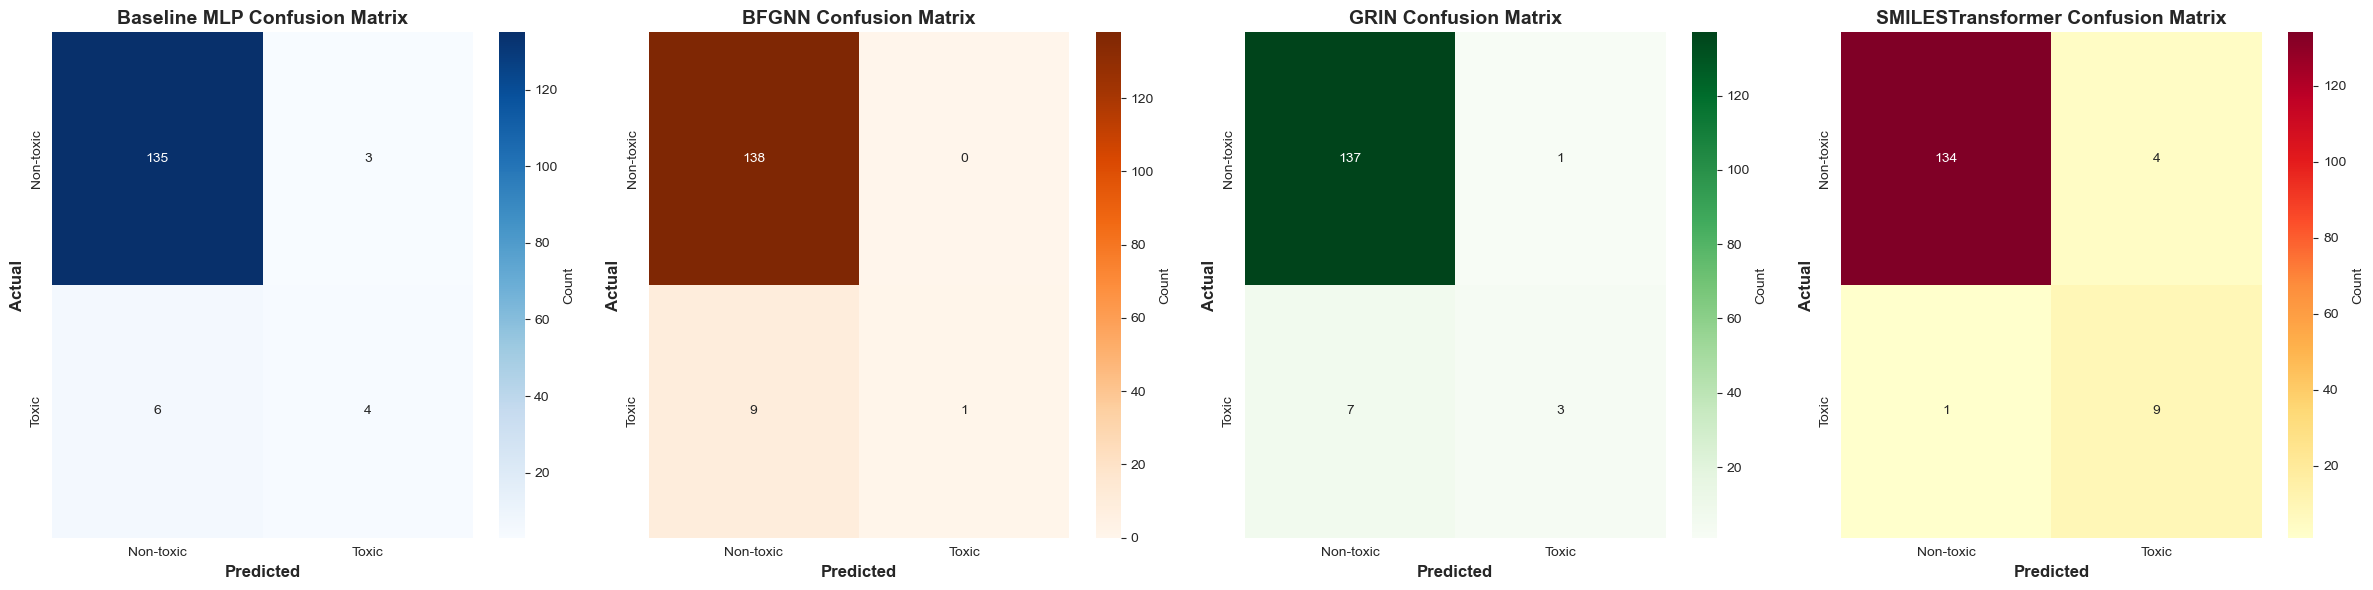


Classification Summary

MLP:
  True Negatives (TN): 135
  False Positives (FP): 3
  False Negatives (FN): 6
  True Positives (TP): 4

BFGNN:
  True Negatives (TN): 138
  False Positives (FP): 0
  False Negatives (FN): 9
  True Positives (TP): 1

GRIN:
  True Negatives (TN): 137
  False Positives (FP): 1
  False Negatives (FN): 7
  True Positives (TP): 3

SMILESTRANSFORMER:
  True Negatives (TN): 134
  False Positives (FP): 4
  False Negatives (FN): 1
  True Positives (TP): 9


In [5]:
# Plot confusion matrices for all available models
from sklearn.metrics import confusion_matrix

n_models = sum([mlp_predictions is not None, bfgnn_predictions is not None, grin_predictions is not None, smilestransformer_predictions is not None])
confusion_stats = {}

if n_models > 0:
    fig, axes = plt.subplots(1, n_models, figsize=(6*n_models, 6))
    if n_models == 1:
        axes = [axes]
    ax_idx = 0
    
    if mlp_predictions is not None:
        mlp_pred = (mlp_predictions > 0.5).astype(int)
        cm_mlp = confusion_matrix(test_labels, mlp_pred)
        sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=['Non-toxic', 'Toxic'],
                    yticklabels=['Non-toxic', 'Toxic'],
                    ax=axes[ax_idx], cbar_kws={'label': 'Count'})
        axes[ax_idx].set_xlabel('Predicted', fontsize=12, fontweight='bold')
        axes[ax_idx].set_ylabel('Actual', fontsize=12, fontweight='bold')
        axes[ax_idx].set_title('Baseline MLP Confusion Matrix', fontsize=14, fontweight='bold')
        confusion_stats['mlp'] = {
            'TN': int(cm_mlp[0,0]),
            'FP': int(cm_mlp[0,1]),
            'FN': int(cm_mlp[1,0]),
            'TP': int(cm_mlp[1,1])
        }
        ax_idx += 1
    
    if bfgnn_predictions is not None:
        bfgnn_pred = (bfgnn_predictions > 0.5).astype(int)
        cm_bfgnn = confusion_matrix(test_labels, bfgnn_pred)
        sns.heatmap(cm_bfgnn, annot=True, fmt='d', cmap='Oranges',
                    xticklabels=['Non-toxic', 'Toxic'],
                    yticklabels=['Non-toxic', 'Toxic'],
                    ax=axes[ax_idx], cbar_kws={'label': 'Count'})
        axes[ax_idx].set_xlabel('Predicted', fontsize=12, fontweight='bold')
        axes[ax_idx].set_ylabel('Actual', fontsize=12, fontweight='bold')
        axes[ax_idx].set_title('BFGNN Confusion Matrix', fontsize=14, fontweight='bold')
        confusion_stats['bfgnn'] = {
            'TN': int(cm_bfgnn[0,0]),
            'FP': int(cm_bfgnn[0,1]),
            'FN': int(cm_bfgnn[1,0]),
            'TP': int(cm_bfgnn[1,1])
        }
        ax_idx += 1
    
    if grin_predictions is not None:
        grin_pred = (grin_predictions > 0.5).astype(int)
        cm_grin = confusion_matrix(test_labels, grin_pred)
        sns.heatmap(cm_grin, annot=True, fmt='d', cmap='Greens',
                    xticklabels=['Non-toxic', 'Toxic'],
                    yticklabels=['Non-toxic', 'Toxic'],
                    ax=axes[ax_idx], cbar_kws={'label': 'Count'})
        axes[ax_idx].set_xlabel('Predicted', fontsize=12, fontweight='bold')
        axes[ax_idx].set_ylabel('Actual', fontsize=12, fontweight='bold')
        axes[ax_idx].set_title('GRIN Confusion Matrix', fontsize=14, fontweight='bold')
        confusion_stats['grin'] = {
            'TN': int(cm_grin[0,0]),
            'FP': int(cm_grin[0,1]),
            'FN': int(cm_grin[1,0]),
            'TP': int(cm_grin[1,1])
        }
        ax_idx += 1
    
    if smilestransformer_predictions is not None:
        smilestransformer_pred = (smilestransformer_predictions > 0.5).astype(int)
        cm_smilestransformer = confusion_matrix(test_labels, smilestransformer_pred)
        sns.heatmap(cm_smilestransformer, annot=True, fmt='d', cmap='YlOrRd',
                    xticklabels=['Non-toxic', 'Toxic'],
                    yticklabels=['Non-toxic', 'Toxic'],
                    ax=axes[ax_idx], cbar_kws={'label': 'Count'})
        axes[ax_idx].set_xlabel('Predicted', fontsize=12, fontweight='bold')
        axes[ax_idx].set_ylabel('Actual', fontsize=12, fontweight='bold')
        axes[ax_idx].set_title('SMILESTransformer Confusion Matrix', fontsize=14, fontweight='bold')
        confusion_stats['smilestransformer'] = {
            'TN': int(cm_smilestransformer[0,0]),
            'FP': int(cm_smilestransformer[0,1]),
            'FN': int(cm_smilestransformer[1,0]),
            'TP': int(cm_smilestransformer[1,1])
        }
        ax_idx += 1
    
    plt.tight_layout()
    plt.savefig(figures_dir / "05_confusion_matrices.png", dpi=300, bbox_inches='tight')
    print(f"✓ Confusion matrices saved to: {figures_dir / '05_confusion_matrices.png'}")
    plt.show()
    
    # Print summary statistics
    if confusion_stats:
        print("\n" + "="*60)
        print("Classification Summary")
        print("="*60)
        for model_name, stats in confusion_stats.items():
            print(f"\n{model_name.upper()}:")
            print(f"  True Negatives (TN): {stats['TN']}")
            print(f"  False Positives (FP): {stats['FP']}")
            print(f"  False Negatives (FN): {stats['FN']}")
            print(f"  True Positives (TP): {stats['TP']}")


## Prediction Probability Distributions

Visualize the distribution of prediction probabilities for all models, separated by true label.


✓ Prediction distributions saved to: /Users/nguyennghia/PROJECT/Torch_molecule/output/figures/05_prediction_distributions.png


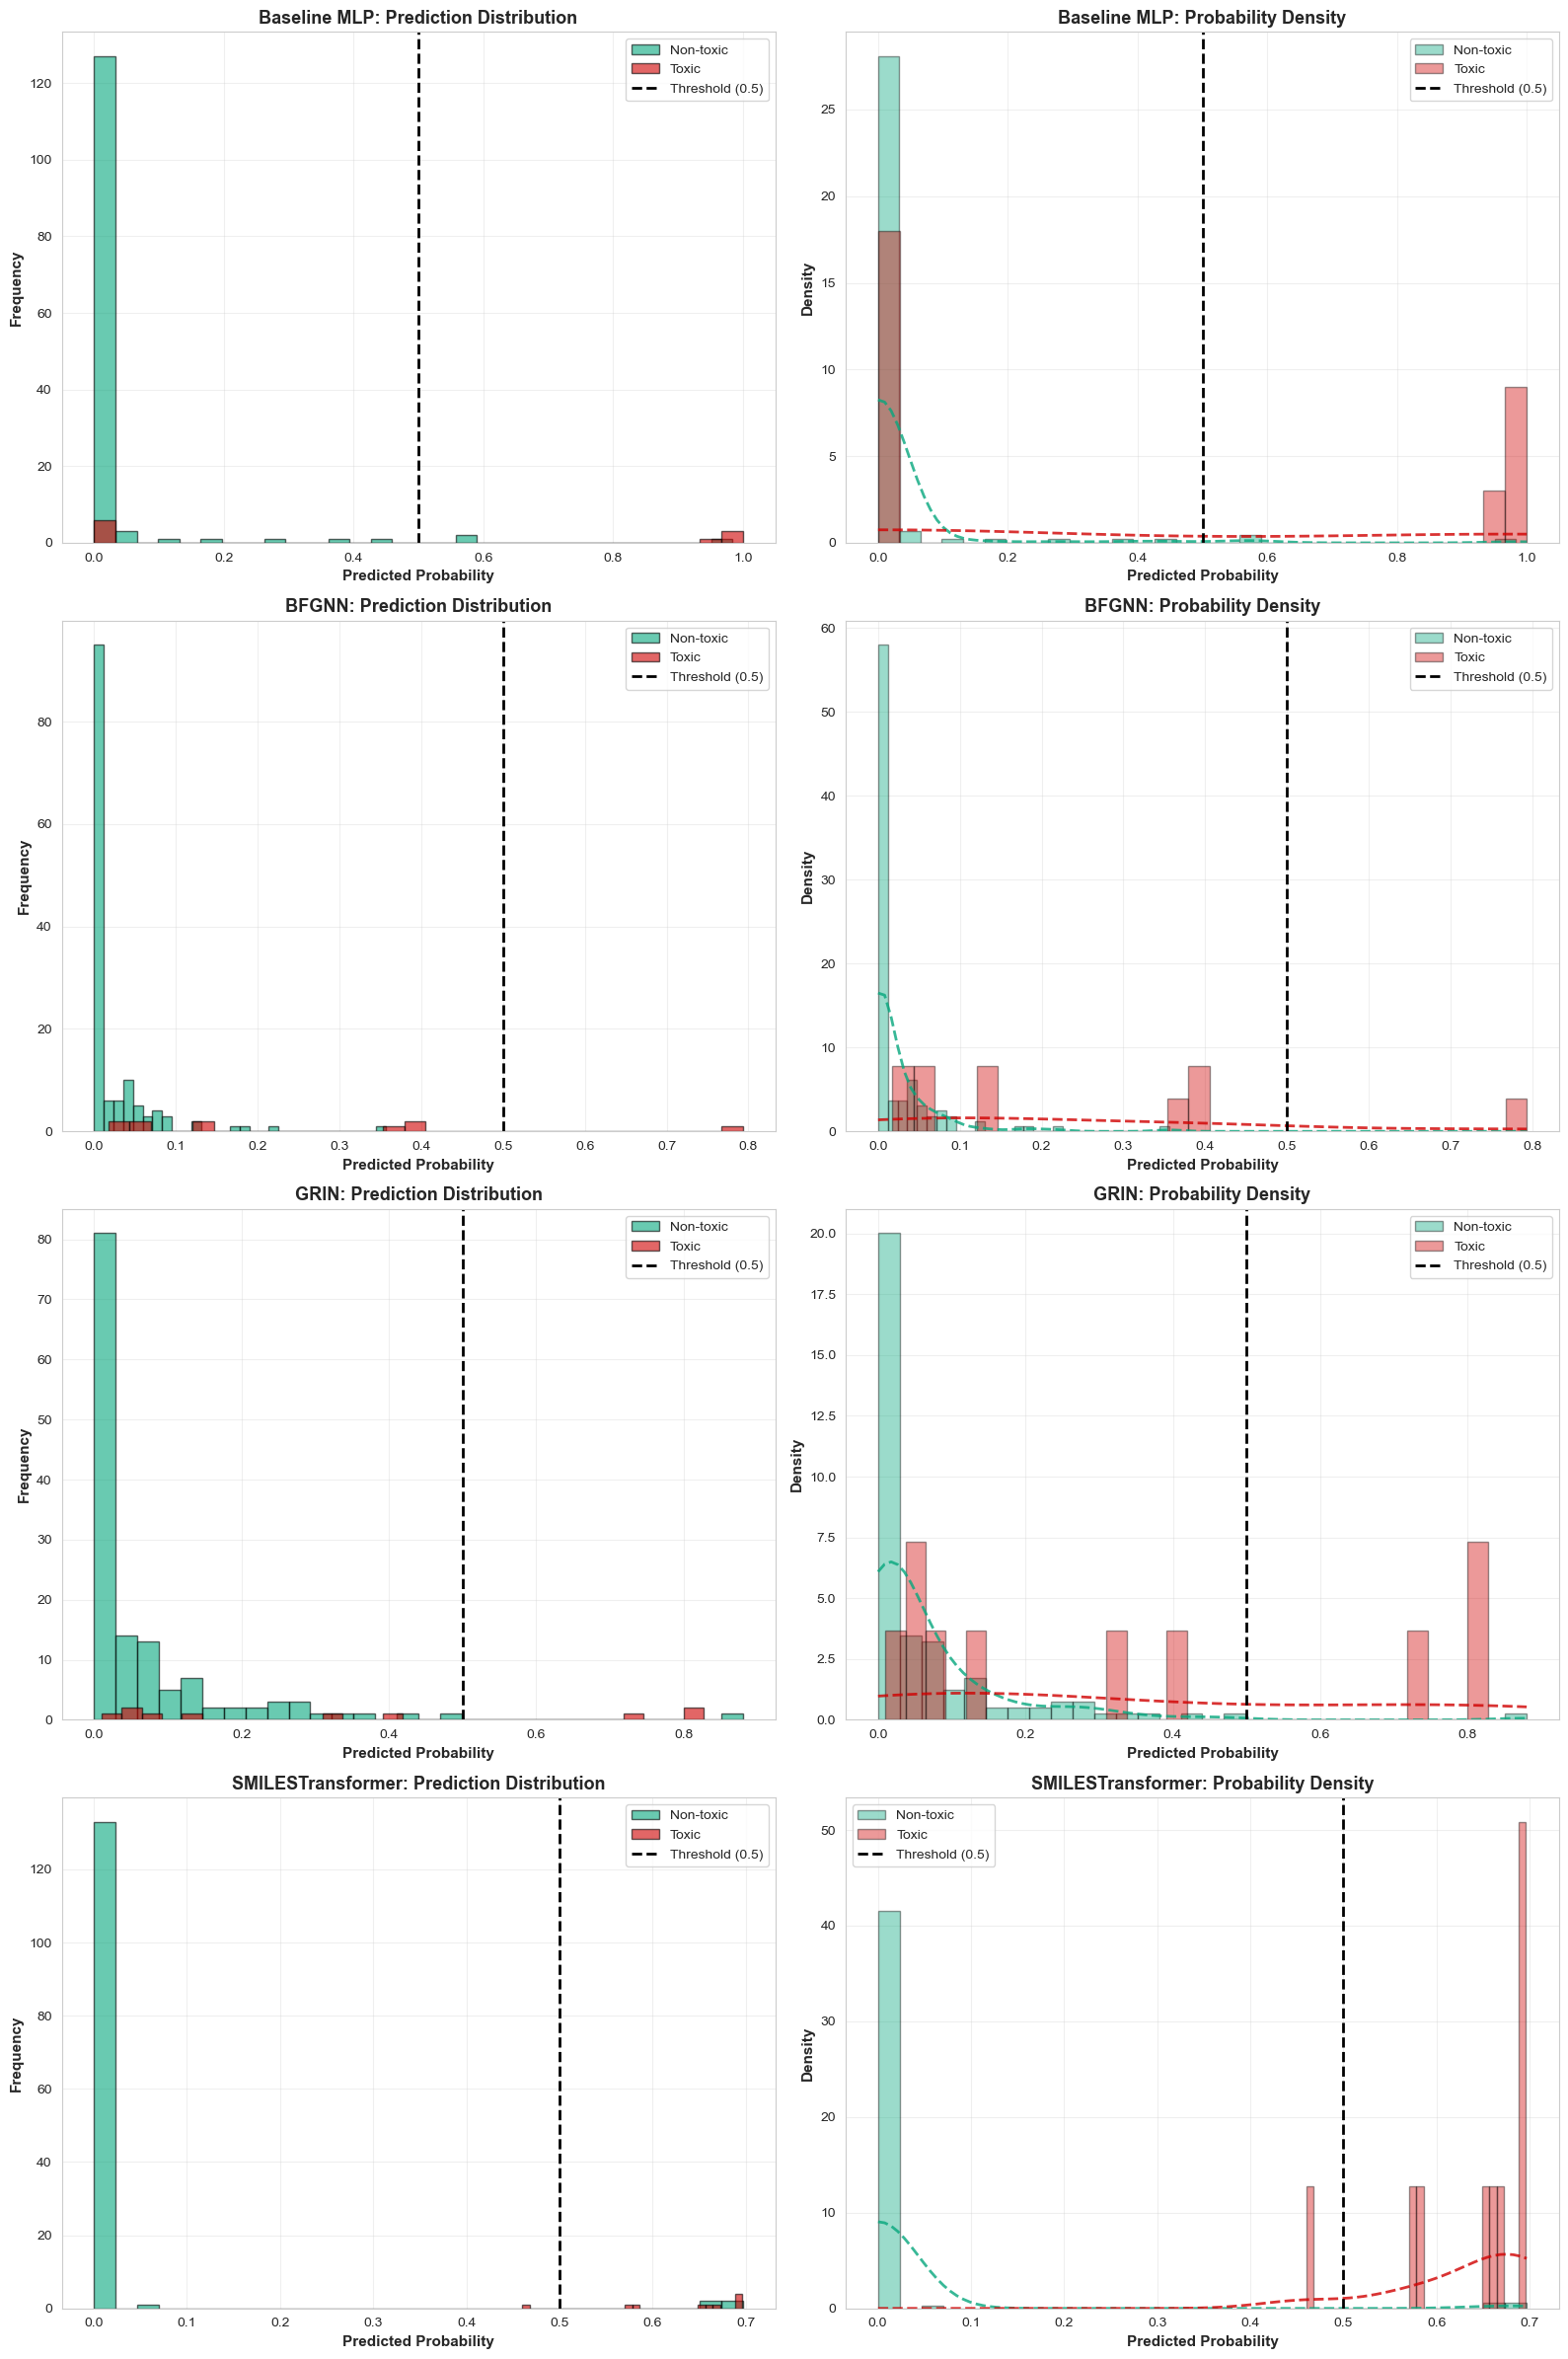

In [6]:
# Plot prediction distributions for all available models
n_models = sum([mlp_predictions is not None, bfgnn_predictions is not None, grin_predictions is not None, smilestransformer_predictions is not None])

if n_models > 0:
    # Use appropriate grid: 4 rows if we have 4 models, 3 rows if 3, 2 rows otherwise
    if n_models == 4:
        fig, axes = plt.subplots(4, 2, figsize=(16, 24))
    elif n_models == 3:
        fig, axes = plt.subplots(3, 2, figsize=(16, 18))
    else:
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    row = 0
    
    # MLP distributions
    if mlp_predictions is not None:
        mlp_toxic = mlp_predictions[test_labels == 1]
        mlp_nontoxic = mlp_predictions[test_labels == 0]
        
        axes[row, 0].hist(mlp_nontoxic, bins=30, alpha=0.6, label='Non-toxic', 
                         color='#06A77D', edgecolor='black')
        axes[row, 0].hist(mlp_toxic, bins=30, alpha=0.6, label='Toxic', 
                         color='#D00000', edgecolor='black')
        axes[row, 0].axvline(x=0.5, color='k', linestyle='--', linewidth=2, label='Threshold (0.5)')
        axes[row, 0].set_xlabel('Predicted Probability', fontsize=11, fontweight='bold')
        axes[row, 0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
        axes[row, 0].set_title('Baseline MLP: Prediction Distribution', fontsize=13, fontweight='bold')
        axes[row, 0].legend()
        axes[row, 0].grid(True, alpha=0.3)
        
        # KDE plot
        axes[row, 1].hist(mlp_nontoxic, bins=30, alpha=0.4, density=True, 
                         label='Non-toxic', color='#06A77D', edgecolor='black')
        axes[row, 1].hist(mlp_toxic, bins=30, alpha=0.4, density=True, 
                         label='Toxic', color='#D00000', edgecolor='black')
        try:
            from scipy import stats
            if len(mlp_nontoxic) > 1 and mlp_nontoxic.std() > 0:
                x = np.linspace(mlp_predictions.min(), mlp_predictions.max(), 100)
                axes[row, 1].plot(x, stats.gaussian_kde(mlp_nontoxic)(x), 
                                '--', linewidth=2, color='#06A77D', alpha=0.8)
            if len(mlp_toxic) > 1 and mlp_toxic.std() > 0:
                x = np.linspace(mlp_predictions.min(), mlp_predictions.max(), 100)
                axes[row, 1].plot(x, stats.gaussian_kde(mlp_toxic)(x), 
                                '--', linewidth=2, color='#D00000', alpha=0.8)
        except:
            pass
        axes[row, 1].axvline(x=0.5, color='k', linestyle='--', linewidth=2, label='Threshold (0.5)')
        axes[row, 1].set_xlabel('Predicted Probability', fontsize=11, fontweight='bold')
        axes[row, 1].set_ylabel('Density', fontsize=11, fontweight='bold')
        axes[row, 1].set_title('Baseline MLP: Probability Density', fontsize=13, fontweight='bold')
        axes[row, 1].legend()
        axes[row, 1].grid(True, alpha=0.3)
        row += 1
    
    # BFGNN distributions
    if bfgnn_predictions is not None:
        bfgnn_toxic = bfgnn_predictions[test_labels == 1]
        bfgnn_nontoxic = bfgnn_predictions[test_labels == 0]
        
        axes[row, 0].hist(bfgnn_nontoxic, bins=30, alpha=0.6, label='Non-toxic', 
                         color='#06A77D', edgecolor='black')
        axes[row, 0].hist(bfgnn_toxic, bins=30, alpha=0.6, label='Toxic', 
                         color='#D00000', edgecolor='black')
        axes[row, 0].axvline(x=0.5, color='k', linestyle='--', linewidth=2, label='Threshold (0.5)')
        axes[row, 0].set_xlabel('Predicted Probability', fontsize=11, fontweight='bold')
        axes[row, 0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
        axes[row, 0].set_title('BFGNN: Prediction Distribution', fontsize=13, fontweight='bold')
        axes[row, 0].legend()
        axes[row, 0].grid(True, alpha=0.3)
        
        # KDE plot
        axes[row, 1].hist(bfgnn_nontoxic, bins=30, alpha=0.4, density=True, 
                         label='Non-toxic', color='#06A77D', edgecolor='black')
        axes[row, 1].hist(bfgnn_toxic, bins=30, alpha=0.4, density=True, 
                         label='Toxic', color='#D00000', edgecolor='black')
        try:
            from scipy import stats
            if len(bfgnn_nontoxic) > 1 and bfgnn_nontoxic.std() > 0:
                x = np.linspace(bfgnn_predictions.min(), bfgnn_predictions.max(), 100)
                axes[row, 1].plot(x, stats.gaussian_kde(bfgnn_nontoxic)(x), 
                                '--', linewidth=2, color='#06A77D', alpha=0.8)
            if len(bfgnn_toxic) > 1 and bfgnn_toxic.std() > 0:
                x = np.linspace(bfgnn_predictions.min(), bfgnn_predictions.max(), 100)
                axes[row, 1].plot(x, stats.gaussian_kde(bfgnn_toxic)(x), 
                                '--', linewidth=2, color='#D00000', alpha=0.8)
        except:
            pass
        axes[row, 1].axvline(x=0.5, color='k', linestyle='--', linewidth=2, label='Threshold (0.5)')
        axes[row, 1].set_xlabel('Predicted Probability', fontsize=11, fontweight='bold')
        axes[row, 1].set_ylabel('Density', fontsize=11, fontweight='bold')
        axes[row, 1].set_title('BFGNN: Probability Density', fontsize=13, fontweight='bold')
        axes[row, 1].legend()
        axes[row, 1].grid(True, alpha=0.3)
        row += 1
    
    # GRIN distributions
    if grin_predictions is not None:
        grin_toxic = grin_predictions[test_labels == 1]
        grin_nontoxic = grin_predictions[test_labels == 0]
        
        axes[row, 0].hist(grin_nontoxic, bins=30, alpha=0.6, label='Non-toxic', 
                         color='#06A77D', edgecolor='black')
        axes[row, 0].hist(grin_toxic, bins=30, alpha=0.6, label='Toxic', 
                         color='#D00000', edgecolor='black')
        axes[row, 0].axvline(x=0.5, color='k', linestyle='--', linewidth=2, label='Threshold (0.5)')
        axes[row, 0].set_xlabel('Predicted Probability', fontsize=11, fontweight='bold')
        axes[row, 0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
        axes[row, 0].set_title('GRIN: Prediction Distribution', fontsize=13, fontweight='bold')
        axes[row, 0].legend()
        axes[row, 0].grid(True, alpha=0.3)
        
        # KDE plot
        axes[row, 1].hist(grin_nontoxic, bins=30, alpha=0.4, density=True, 
                         label='Non-toxic', color='#06A77D', edgecolor='black')
        axes[row, 1].hist(grin_toxic, bins=30, alpha=0.4, density=True, 
                         label='Toxic', color='#D00000', edgecolor='black')
        try:
            from scipy import stats
            if len(grin_nontoxic) > 1 and grin_nontoxic.std() > 0:
                x = np.linspace(grin_predictions.min(), grin_predictions.max(), 100)
                axes[row, 1].plot(x, stats.gaussian_kde(grin_nontoxic)(x), 
                                '--', linewidth=2, color='#06A77D', alpha=0.8)
            if len(grin_toxic) > 1 and grin_toxic.std() > 0:
                x = np.linspace(grin_predictions.min(), grin_predictions.max(), 100)
                axes[row, 1].plot(x, stats.gaussian_kde(grin_toxic)(x), 
                                '--', linewidth=2, color='#D00000', alpha=0.8)
        except:
            pass
        axes[row, 1].axvline(x=0.5, color='k', linestyle='--', linewidth=2, label='Threshold (0.5)')
        axes[row, 1].set_xlabel('Predicted Probability', fontsize=11, fontweight='bold')
        axes[row, 1].set_ylabel('Density', fontsize=11, fontweight='bold')
        axes[row, 1].set_title('GRIN: Probability Density', fontsize=13, fontweight='bold')
        axes[row, 1].legend()
        axes[row, 1].grid(True, alpha=0.3)
        row += 1
    
    # SMILESTransformer distributions
    if smilestransformer_predictions is not None:
        smilestransformer_toxic = smilestransformer_predictions[test_labels == 1]
        smilestransformer_nontoxic = smilestransformer_predictions[test_labels == 0]
        
        axes[row, 0].hist(smilestransformer_nontoxic, bins=30, alpha=0.6, label='Non-toxic', 
                         color='#06A77D', edgecolor='black')
        axes[row, 0].hist(smilestransformer_toxic, bins=30, alpha=0.6, label='Toxic', 
                         color='#D00000', edgecolor='black')
        axes[row, 0].axvline(x=0.5, color='k', linestyle='--', linewidth=2, label='Threshold (0.5)')
        axes[row, 0].set_xlabel('Predicted Probability', fontsize=11, fontweight='bold')
        axes[row, 0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
        axes[row, 0].set_title('SMILESTransformer: Prediction Distribution', fontsize=13, fontweight='bold')
        axes[row, 0].legend()
        axes[row, 0].grid(True, alpha=0.3)
        
        # KDE plot
        axes[row, 1].hist(smilestransformer_nontoxic, bins=30, alpha=0.4, density=True, 
                         label='Non-toxic', color='#06A77D', edgecolor='black')
        axes[row, 1].hist(smilestransformer_toxic, bins=30, alpha=0.4, density=True, 
                         label='Toxic', color='#D00000', edgecolor='black')
        try:
            from scipy import stats
            if len(smilestransformer_nontoxic) > 1 and smilestransformer_nontoxic.std() > 0:
                x = np.linspace(smilestransformer_predictions.min(), smilestransformer_predictions.max(), 100)
                axes[row, 1].plot(x, stats.gaussian_kde(smilestransformer_nontoxic)(x), 
                                '--', linewidth=2, color='#06A77D', alpha=0.8)
            if len(smilestransformer_toxic) > 1 and smilestransformer_toxic.std() > 0:
                x = np.linspace(smilestransformer_predictions.min(), smilestransformer_predictions.max(), 100)
                axes[row, 1].plot(x, stats.gaussian_kde(smilestransformer_toxic)(x), 
                                '--', linewidth=2, color='#D00000', alpha=0.8)
        except:
            pass
        axes[row, 1].axvline(x=0.5, color='k', linestyle='--', linewidth=2, label='Threshold (0.5)')
        axes[row, 1].set_xlabel('Predicted Probability', fontsize=11, fontweight='bold')
        axes[row, 1].set_ylabel('Density', fontsize=11, fontweight='bold')
        axes[row, 1].set_title('SMILESTransformer: Probability Density', fontsize=13, fontweight='bold')
        axes[row, 1].legend()
        axes[row, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(figures_dir / "05_prediction_distributions.png", dpi=300, bbox_inches='tight')
    print(f"✓ Prediction distributions saved to: {figures_dir / '05_prediction_distributions.png'}")
    plt.show()


## ROC and Precision-Recall Curves

Compare the models' ability to distinguish between toxic and non-toxic compounds using ROC and PR curves.


✓ ROC and PR curves saved to: /Users/nguyennghia/PROJECT/Torch_molecule/output/figures/05_roc_pr_curves.png


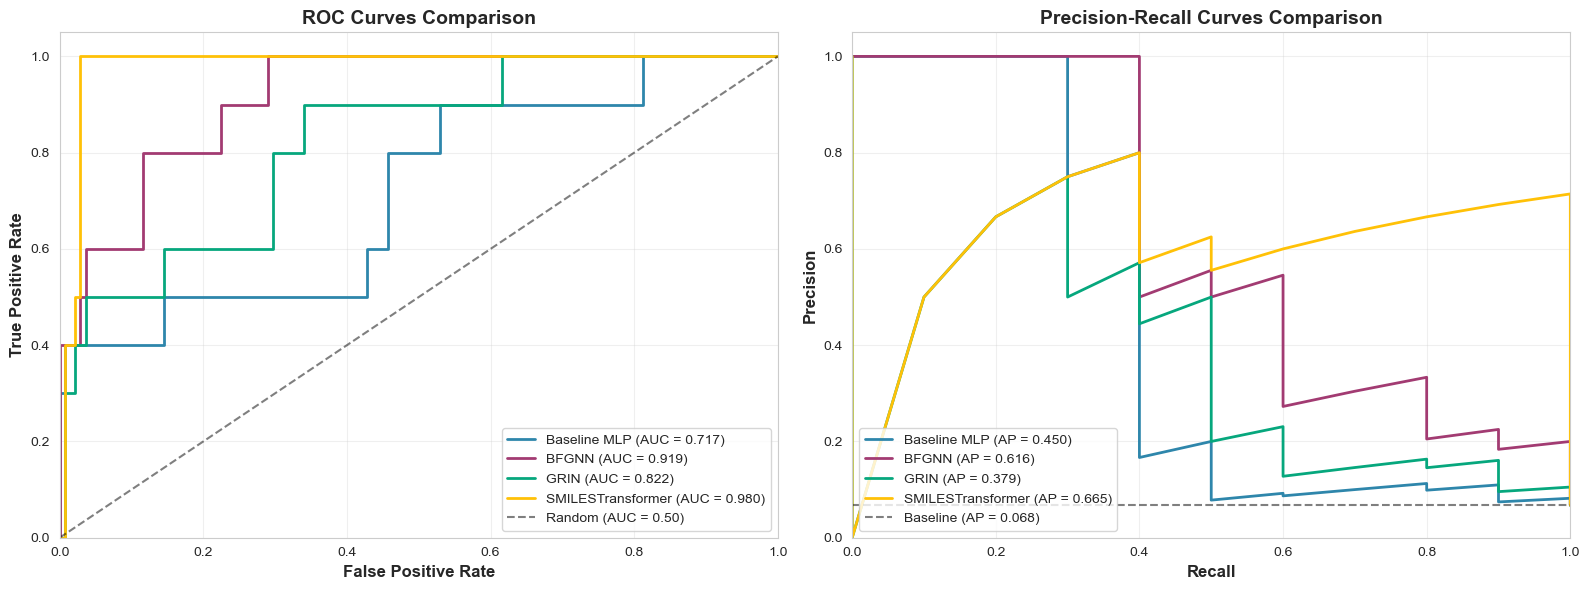

In [7]:
# Plot ROC and PR curves with all available models
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curves
if mlp_predictions is not None:
    fpr_mlp, tpr_mlp, _ = roc_curve(test_labels, mlp_predictions)
    roc_auc_mlp = roc_auc_score(test_labels, mlp_predictions)
    axes[0].plot(fpr_mlp, tpr_mlp, 
                label=f'Baseline MLP (AUC = {roc_auc_mlp:.3f})', 
                linewidth=2, color='#2E86AB')

if bfgnn_predictions is not None:
    fpr_bfgnn, tpr_bfgnn, _ = roc_curve(test_labels, bfgnn_predictions)
    roc_auc_bfgnn = roc_auc_score(test_labels, bfgnn_predictions)
    axes[0].plot(fpr_bfgnn, tpr_bfgnn, 
                label=f'BFGNN (AUC = {roc_auc_bfgnn:.3f})', 
                linewidth=2, color='#A23B72')

if grin_predictions is not None:
    fpr_grin, tpr_grin, _ = roc_curve(test_labels, grin_predictions)
    roc_auc_grin = roc_auc_score(test_labels, grin_predictions)
    axes[0].plot(fpr_grin, tpr_grin, 
                label=f'GRIN (AUC = {roc_auc_grin:.3f})', 
                linewidth=2, color='#06A77D')

if smilestransformer_predictions is not None:
    fpr_smilestransformer, tpr_smilestransformer, _ = roc_curve(test_labels, smilestransformer_predictions)
    roc_auc_smilestransformer = roc_auc_score(test_labels, smilestransformer_predictions)
    axes[0].plot(fpr_smilestransformer, tpr_smilestransformer, 
                label=f'SMILESTransformer (AUC = {roc_auc_smilestransformer:.3f})', 
                linewidth=2, color='#FFC107')

axes[0].plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)', alpha=0.5)
axes[0].set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
axes[0].set_title('ROC Curves Comparison', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])

# Precision-Recall Curves
if mlp_predictions is not None:
    precision_mlp, recall_mlp, _ = precision_recall_curve(test_labels, mlp_predictions)
    pr_auc_mlp = average_precision_score(test_labels, mlp_predictions)
    axes[1].plot(recall_mlp, precision_mlp, 
                label=f'Baseline MLP (AP = {pr_auc_mlp:.3f})', 
                linewidth=2, color='#2E86AB')

if bfgnn_predictions is not None:
    precision_bfgnn, recall_bfgnn, _ = precision_recall_curve(test_labels, bfgnn_predictions)
    pr_auc_bfgnn = average_precision_score(test_labels, bfgnn_predictions)
    axes[1].plot(recall_bfgnn, precision_bfgnn, 
                label=f'BFGNN (AP = {pr_auc_bfgnn:.3f})', 
                linewidth=2, color='#A23B72')

if grin_predictions is not None:
    precision_grin, recall_grin, _ = precision_recall_curve(test_labels, grin_predictions)
    pr_auc_grin = average_precision_score(test_labels, grin_predictions)
    axes[1].plot(recall_grin, precision_grin, 
                label=f'GRIN (AP = {pr_auc_grin:.3f})', 
                linewidth=2, color='#06A77D')

if smilestransformer_predictions is not None:
    precision_smilestransformer, recall_smilestransformer, _ = precision_recall_curve(test_labels, smilestransformer_predictions)
    pr_auc_smilestransformer = average_precision_score(test_labels, smilestransformer_predictions)
    axes[1].plot(recall_smilestransformer, precision_smilestransformer, 
                label=f'SMILESTransformer (AP = {pr_auc_smilestransformer:.3f})', 
                linewidth=2, color='#FFC107')

baseline_pr = test_labels.mean()
axes[1].axhline(y=baseline_pr, color='k', linestyle='--', 
               label=f'Baseline (AP = {baseline_pr:.3f})', alpha=0.5)
axes[1].set_xlabel('Recall', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Precision', fontsize=12, fontweight='bold')
axes[1].set_title('Precision-Recall Curves Comparison', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower left', fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])

plt.tight_layout()
plt.savefig(figures_dir / "05_roc_pr_curves.png", dpi=300, bbox_inches='tight')
print(f"✓ ROC and PR curves saved to: {figures_dir / '05_roc_pr_curves.png'}")
plt.show()


## Prediction Probability Distributions

Compare how both models distribute their prediction probabilities for toxic vs non-toxic compounds.


✓ Prediction distributions saved to: /Users/nguyennghia/PROJECT/Torch_molecule/output/figures/05_prediction_distributions.png


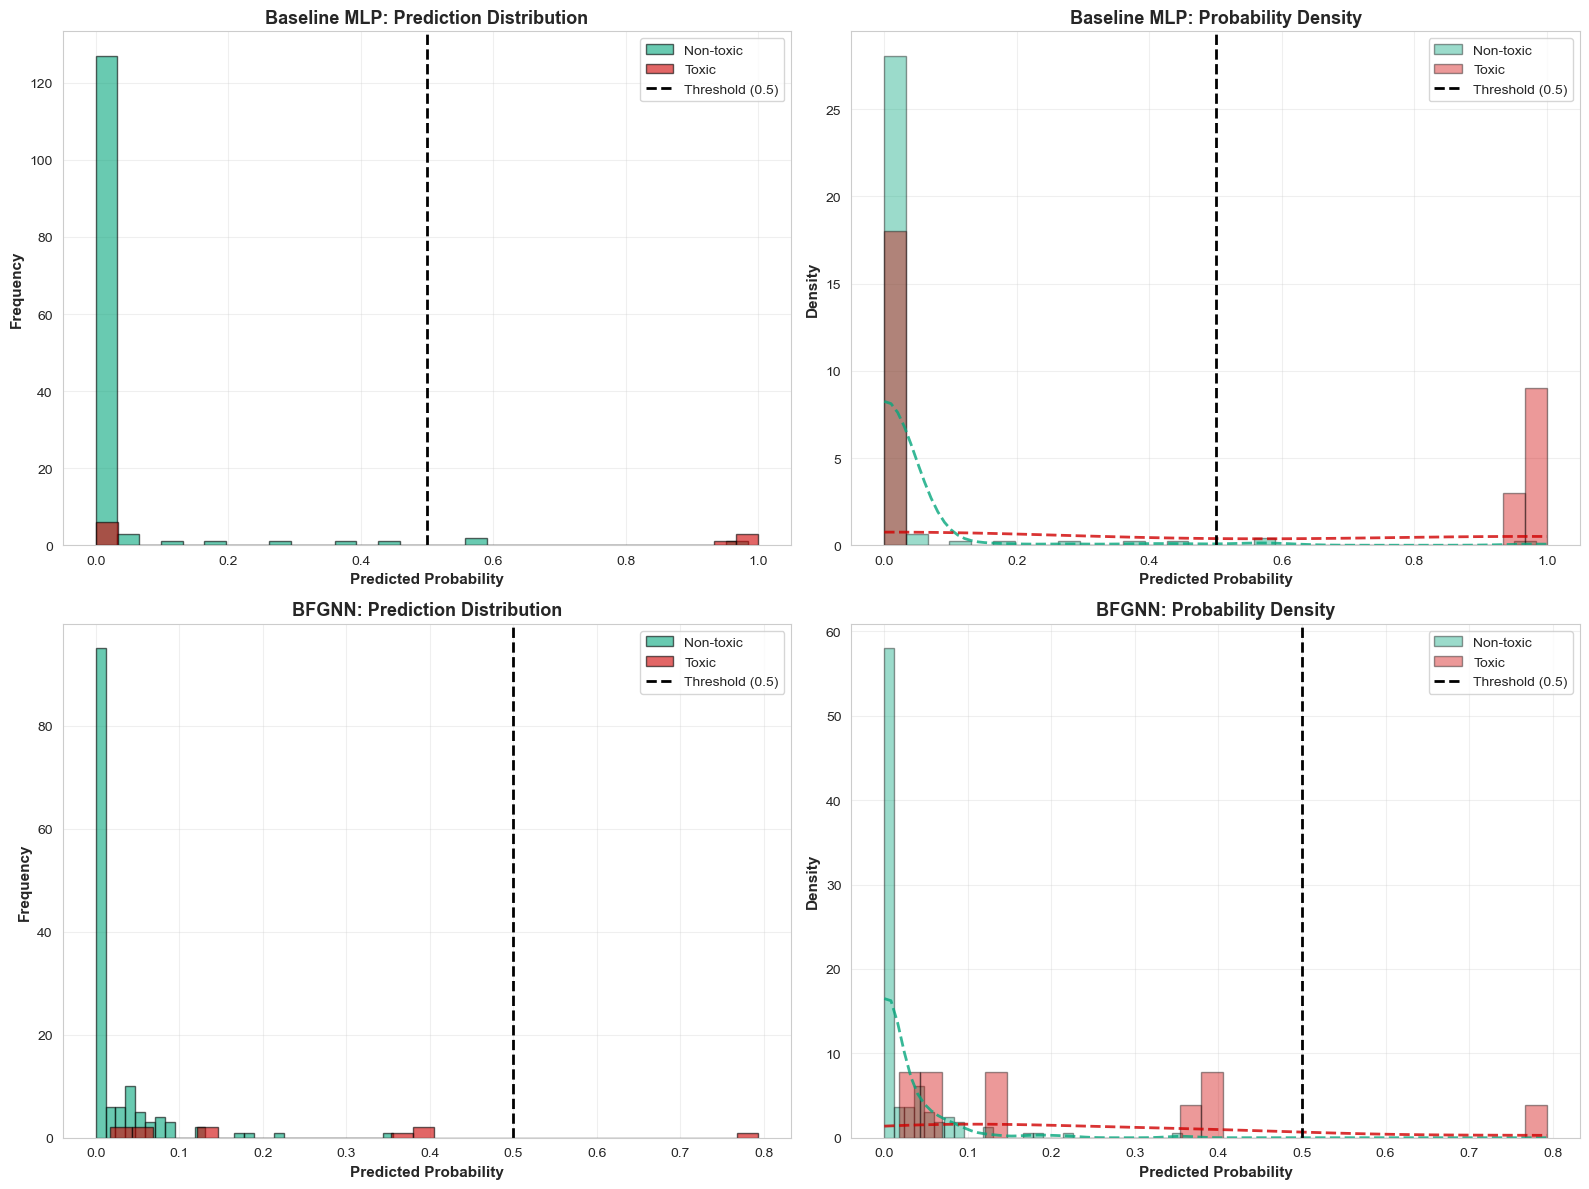

In [8]:
if mlp_predictions is not None and bfgnn_predictions is not None:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Separate predictions by true label
    mlp_toxic = mlp_predictions[test_labels == 1]
    mlp_nontoxic = mlp_predictions[test_labels == 0]
    bfgnn_toxic = bfgnn_predictions[test_labels == 1]
    bfgnn_nontoxic = bfgnn_predictions[test_labels == 0]
    
    # Baseline MLP - Histogram
    axes[0, 0].hist(mlp_nontoxic, bins=30, alpha=0.6, label='Non-toxic', 
                   color='#06A77D', edgecolor='black')
    axes[0, 0].hist(mlp_toxic, bins=30, alpha=0.6, label='Toxic', 
                   color='#D00000', edgecolor='black')
    axes[0, 0].axvline(x=0.5, color='k', linestyle='--', linewidth=2, label='Threshold (0.5)')
    axes[0, 0].set_xlabel('Predicted Probability', fontsize=11, fontweight='bold')
    axes[0, 0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
    axes[0, 0].set_title('Baseline MLP: Prediction Distribution', fontsize=13, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Baseline MLP - KDE
    axes[0, 1].hist(mlp_nontoxic, bins=30, alpha=0.4, density=True, 
                   label='Non-toxic', color='#06A77D', edgecolor='black')
    axes[0, 1].hist(mlp_toxic, bins=30, alpha=0.4, density=True, 
                   label='Toxic', color='#D00000', edgecolor='black')
    try:
        from scipy import stats
        if len(mlp_nontoxic) > 1:
            x = np.linspace(mlp_predictions.min(), mlp_predictions.max(), 100)
            if mlp_nontoxic.std() > 0:
                axes[0, 1].plot(x, stats.gaussian_kde(mlp_nontoxic)(x), 
                              '--', linewidth=2, color='#06A77D', alpha=0.8)
        if len(mlp_toxic) > 1:
            x = np.linspace(mlp_predictions.min(), mlp_predictions.max(), 100)
            if mlp_toxic.std() > 0:
                axes[0, 1].plot(x, stats.gaussian_kde(mlp_toxic)(x), 
                              '--', linewidth=2, color='#D00000', alpha=0.8)
    except:
        pass
    axes[0, 1].axvline(x=0.5, color='k', linestyle='--', linewidth=2, label='Threshold (0.5)')
    axes[0, 1].set_xlabel('Predicted Probability', fontsize=11, fontweight='bold')
    axes[0, 1].set_ylabel('Density', fontsize=11, fontweight='bold')
    axes[0, 1].set_title('Baseline MLP: Probability Density', fontsize=13, fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # GNN - Histogram
    axes[1, 0].hist(bfgnn_nontoxic, bins=30, alpha=0.6, label='Non-toxic', 
                   color='#06A77D', edgecolor='black')
    axes[1, 0].hist(bfgnn_toxic, bins=30, alpha=0.6, label='Toxic', 
                   color='#D00000', edgecolor='black')
    axes[1, 0].axvline(x=0.5, color='k', linestyle='--', linewidth=2, label='Threshold (0.5)')
    axes[1, 0].set_xlabel('Predicted Probability', fontsize=11, fontweight='bold')
    axes[1, 0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
    axes[1, 0].set_title('BFGNN: Prediction Distribution', fontsize=13, fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # BFGNN - KDE
    axes[1, 1].hist(bfgnn_nontoxic, bins=30, alpha=0.4, density=True, 
                   label='Non-toxic', color='#06A77D', edgecolor='black')
    axes[1, 1].hist(bfgnn_toxic, bins=30, alpha=0.4, density=True, 
                   label='Toxic', color='#D00000', edgecolor='black')
    try:
        from scipy import stats
        if len(bfgnn_nontoxic) > 1:
            x = np.linspace(bfgnn_predictions.min(), bfgnn_predictions.max(), 100)
            if bfgnn_nontoxic.std() > 0:
                axes[1, 1].plot(x, stats.gaussian_kde(bfgnn_nontoxic)(x), 
                              '--', linewidth=2, color='#06A77D', alpha=0.8)
        if len(bfgnn_toxic) > 1:
            x = np.linspace(bfgnn_predictions.min(), bfgnn_predictions.max(), 100)
            if bfgnn_toxic.std() > 0:
                axes[1, 1].plot(x, stats.gaussian_kde(bfgnn_toxic)(x), 
                              '--', linewidth=2, color='#D00000', alpha=0.8)
    except:
        pass
    axes[1, 1].axvline(x=0.5, color='k', linestyle='--', linewidth=2, label='Threshold (0.5)')
    axes[1, 1].set_xlabel('Predicted Probability', fontsize=11, fontweight='bold')
    axes[1, 1].set_ylabel('Density', fontsize=11, fontweight='bold')
    axes[1, 1].set_title('BFGNN: Probability Density', fontsize=13, fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save figure
    plt.savefig(figures_dir / "05_prediction_distributions.png", dpi=300, bbox_inches='tight')
    print(f"✓ Prediction distributions saved to: {figures_dir / '05_prediction_distributions.png'}")
    
    plt.show()
else:
    print("⚠ Both models needed for distribution comparison")


## Model Agreement Analysis

Analyze how well the two models agree on their predictions.


✓ Model agreement visualization saved to: /Users/nguyennghia/PROJECT/Torch_molecule/output/figures/05_model_agreement.png


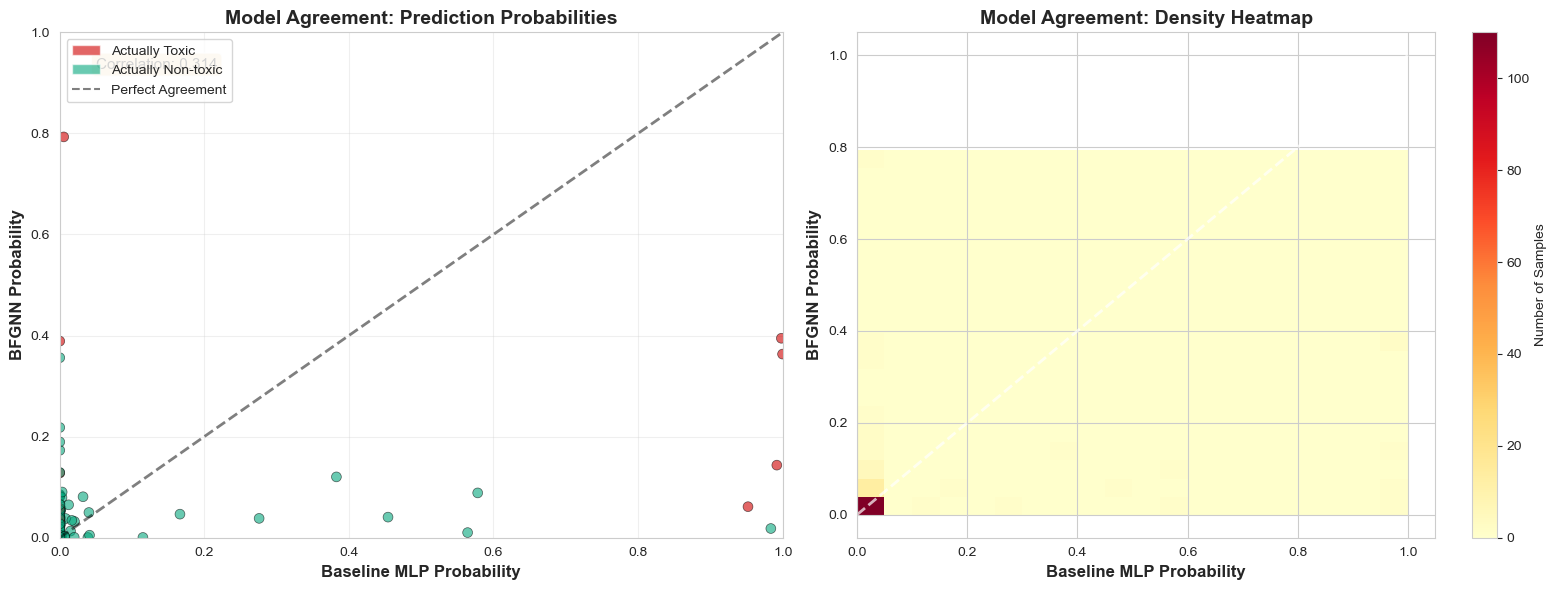


Model Agreement Statistics:
  Binary prediction agreement: 94.59%
  Correlation coefficient: 0.314
  Mean absolute difference: 0.0689

Additional Pairwise Comparisons:

  MLP vs GRIN:
    Correlation: 0.4580
    Mean absolute difference: 0.0899
    Binary prediction agreement: 95.27%

  BFGNN vs GRIN:
    Correlation: 0.5505
    Mean absolute difference: 0.0703
    Binary prediction agreement: 96.62%


In [9]:
if mlp_predictions is not None and bfgnn_predictions is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Scatter plot: MLP vs GNN predictions
    colors = ['#D00000' if label == 1 else '#06A77D' for label in test_labels]
    scatter = axes[0].scatter(mlp_predictions, bfgnn_predictions, 
                             c=colors, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
    axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=2, label='Perfect Agreement')
    axes[0].set_xlabel('Baseline MLP Probability', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('BFGNN Probability', fontsize=12, fontweight='bold')
    axes[0].set_title('Model Agreement: Prediction Probabilities', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim([0, 1])
    axes[0].set_ylim([0, 1])
    
    # Add legend for colors
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#D00000', alpha=0.6, label='Actually Toxic'),
        Patch(facecolor='#06A77D', alpha=0.6, label='Actually Non-toxic'),
        plt.Line2D([0], [0], color='k', linestyle='--', alpha=0.5, label='Perfect Agreement')
    ]
    axes[0].legend(handles=legend_elements, loc='upper left')
    
    # Calculate correlation
    correlation = np.corrcoef(mlp_predictions, bfgnn_predictions)[0, 1]
    axes[0].text(0.05, 0.95, f'Correlation: {correlation:.3f}', 
                transform=axes[0].transAxes, fontsize=11,
                verticalalignment='top', bbox=dict(boxstyle='round', 
                facecolor='wheat', alpha=0.8))
    
    # Agreement heatmap (binned)
    # Create 2D histogram
    H, xedges, yedges = np.histogram2d(mlp_predictions, bfgnn_predictions, bins=20)
    H = H.T  # Transpose for correct orientation
    
    im = axes[1].imshow(H, origin='lower', aspect='auto', cmap='YlOrRd', 
                       extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]])
    axes[1].set_xlabel('Baseline MLP Probability', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('BFGNN Probability', fontsize=12, fontweight='bold')
    axes[1].set_title('Model Agreement: Density Heatmap', fontsize=14, fontweight='bold')
    plt.colorbar(im, ax=axes[1], label='Number of Samples')
    axes[1].plot([0, 1], [0, 1], 'w--', alpha=0.7, linewidth=2)
    
    plt.tight_layout()
    
    # Save figure
    plt.savefig(figures_dir / "05_model_agreement.png", dpi=300, bbox_inches='tight')
    print(f"✓ Model agreement visualization saved to: {figures_dir / '05_model_agreement.png'}")
    
    plt.show()
    
    # Agreement statistics
    mlp_pred_binary = (mlp_predictions > 0.5).astype(int)
    bfgnn_pred_binary = (bfgnn_predictions > 0.5).astype(int)
    agreement = (mlp_pred_binary == bfgnn_pred_binary).mean()
    
    print(f"\nModel Agreement Statistics:")
    print(f"  Binary prediction agreement: {agreement*100:.2f}%")
    print(f"  Correlation coefficient: {correlation:.3f}")
    print(f"  Mean absolute difference: {np.mean(np.abs(mlp_predictions - bfgnn_predictions)):.4f}")
    
    # Additional pairwise comparisons if GRIN is available
    if grin_predictions is not None:
        print(f"\nAdditional Pairwise Comparisons:")
        mlp_grin_corr = np.corrcoef(mlp_predictions, grin_predictions)[0, 1]
        mlp_grin_diff = np.mean(np.abs(mlp_predictions - grin_predictions))
        mlp_grin_agree = np.mean((mlp_predictions > 0.5) == (grin_predictions > 0.5))
        print(f"\n  MLP vs GRIN:")
        print(f"    Correlation: {mlp_grin_corr:.4f}")
        print(f"    Mean absolute difference: {mlp_grin_diff:.4f}")
        print(f"    Binary prediction agreement: {mlp_grin_agree*100:.2f}%")
        
        bfgnn_grin_corr = np.corrcoef(bfgnn_predictions, grin_predictions)[0, 1]
        bfgnn_grin_diff = np.mean(np.abs(bfgnn_predictions - grin_predictions))
        bfgnn_grin_agree = np.mean((bfgnn_predictions > 0.5) == (grin_predictions > 0.5))
        print(f"\n  BFGNN vs GRIN:")
        print(f"    Correlation: {bfgnn_grin_corr:.4f}")
        print(f"    Mean absolute difference: {bfgnn_grin_diff:.4f}")
        print(f"    Binary prediction agreement: {bfgnn_grin_agree*100:.2f}%")
elif mlp_predictions is not None and grin_predictions is not None:
    # MLP vs GRIN only (similar code structure)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    colors = ['#D00000' if label == 1 else '#06A77D' for label in test_labels]
    scatter = axes[0].scatter(mlp_predictions, grin_predictions, 
                             c=colors, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
    axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=2)
    axes[0].set_xlabel('Baseline MLP Probability', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('GRIN Probability', fontsize=12, fontweight='bold')
    axes[0].set_title('Model Agreement: MLP vs GRIN', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    correlation = np.corrcoef(mlp_predictions, grin_predictions)[0, 1]
    axes[0].text(0.05, 0.95, f'Correlation: {correlation:.3f}', 
                transform=axes[0].transAxes, fontsize=11,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    H, xedges, yedges = np.histogram2d(mlp_predictions, grin_predictions, bins=20)
    H = H.T
    im = axes[1].imshow(H, origin='lower', aspect='auto', cmap='YlOrRd', 
                       extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]])
    axes[1].set_xlabel('Baseline MLP Probability', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('GRIN Probability', fontsize=12, fontweight='bold')
    axes[1].set_title('MLP vs GRIN: Density Heatmap', fontsize=14, fontweight='bold')
    plt.colorbar(im, ax=axes[1], label='Number of Samples')
    plt.tight_layout()
    plt.savefig(figures_dir / "05_model_agreement.png", dpi=300, bbox_inches='tight')
    print(f"✓ Model agreement visualization saved")
    plt.show()
    print(f"\nMLP vs GRIN Statistics:")
    print(f"  Correlation: {correlation:.4f}")
    print(f"  Mean absolute difference: {np.mean(np.abs(mlp_predictions - grin_predictions)):.4f}")
    print(f"  Binary prediction agreement: {np.mean((mlp_predictions > 0.5) == (grin_predictions > 0.5))*100:.2f}%")
elif bfgnn_predictions is not None and grin_predictions is not None:
    # BFGNN vs GRIN only
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    colors = ['#D00000' if label == 1 else '#06A77D' for label in test_labels]
    scatter = axes[0].scatter(bfgnn_predictions, grin_predictions, 
                             c=colors, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
    axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=2)
    axes[0].set_xlabel('BFGNN Probability', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('GRIN Probability', fontsize=12, fontweight='bold')
    axes[0].set_title('Model Agreement: BFGNN vs GRIN', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    correlation = np.corrcoef(bfgnn_predictions, grin_predictions)[0, 1]
    axes[0].text(0.05, 0.95, f'Correlation: {correlation:.3f}', 
                transform=axes[0].transAxes, fontsize=11,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    H, xedges, yedges = np.histogram2d(bfgnn_predictions, grin_predictions, bins=20)
    H = H.T
    im = axes[1].imshow(H, origin='lower', aspect='auto', cmap='YlOrRd', 
                       extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]])
    axes[1].set_xlabel('BFGNN Probability', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('GRIN Probability', fontsize=12, fontweight='bold')
    axes[1].set_title('BFGNN vs GRIN: Density Heatmap', fontsize=14, fontweight='bold')
    plt.colorbar(im, ax=axes[1], label='Number of Samples')
    plt.tight_layout()
    plt.savefig(figures_dir / "05_model_agreement.png", dpi=300, bbox_inches='tight')
    print(f"✓ Model agreement visualization saved")
    plt.show()
    print(f"\nBFGNN vs GRIN Statistics:")
    print(f"  Correlation: {correlation:.4f}")
    print(f"  Mean absolute difference: {np.mean(np.abs(bfgnn_predictions - grin_predictions)):.4f}")
    print(f"  Binary prediction agreement: {np.mean((bfgnn_predictions > 0.5) == (grin_predictions > 0.5))*100:.2f}%")
else:
    print("⚠ At least two models needed for agreement analysis")


## Error Overlap Visualization

Visualize which molecules are misclassified by the models. Shows pairwise comparisons and comprehensive overlap statistics for all available models (MLP, BFGNN, GRIN, SMILESTransformer).


✓ Error overlap Venn diagrams saved to: /Users/nguyennghia/PROJECT/Torch_molecule/output/figures/05_error_overlap_venn.png


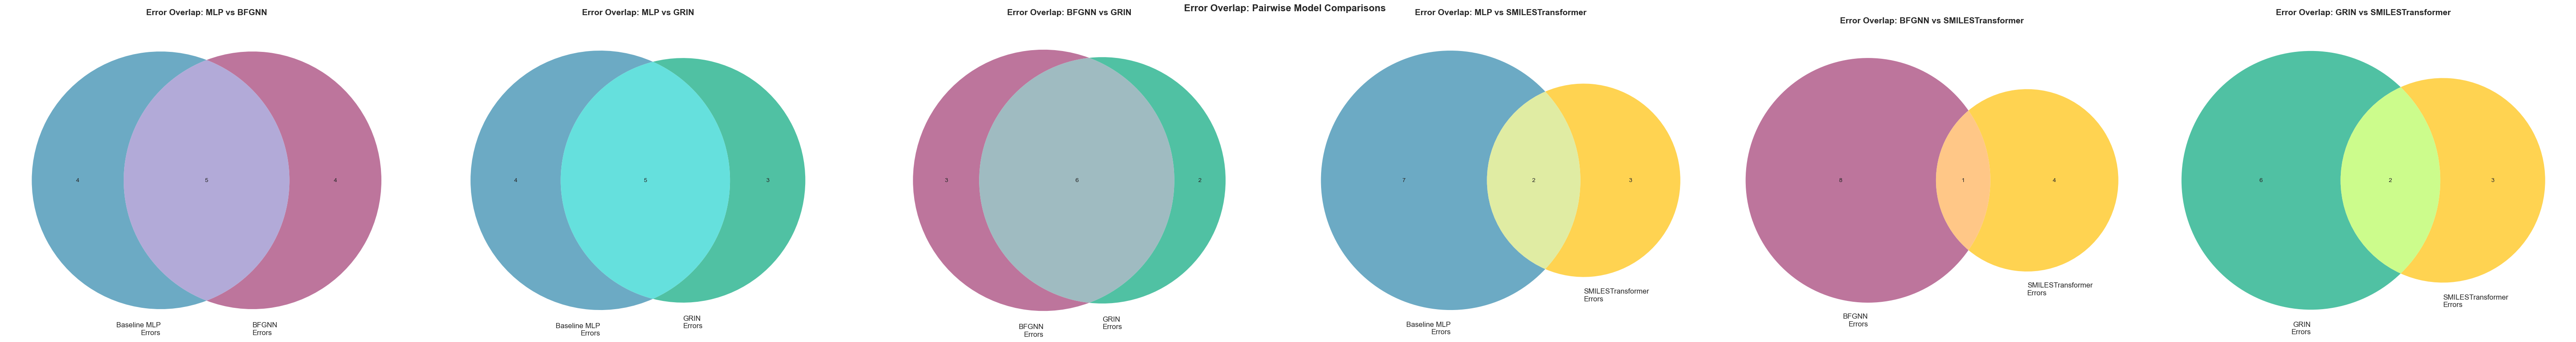


Error Overlap Summary (All Models)

MLP Errors: 9
BFGNN Errors: 9
GRIN Errors: 8
SMILESTransformer Errors: 5

Unique Errors:
  MLP-only: 2
  BFGNN-only: 2
  GRIN-only: 0
  SMILESTransformer-only: 2

Pairwise Overlaps:
  MLP-BFGNN only: 1
  MLP-GRIN only: 1
  MLP-SMILESTransformer only: 1
  BFGNN-GRIN only: 2
  BFGNN-SMILESTransformer only: 0
  GRIN-SMILESTransformer only: 1

Common to All Four Models: 1

Total Unique Errors Across All Models: 16


In [10]:
# Analyze error overlap for all available models
mlp_errors = set()
bfgnn_errors = set()
grin_errors = set()
smilestransformer_errors = set()

if mlp_predictions is not None:
    mlp_pred_binary = (mlp_predictions > 0.5).astype(int)
    mlp_errors = set(np.where(mlp_pred_binary != test_labels)[0])

if bfgnn_predictions is not None:
    bfgnn_pred_binary = (bfgnn_predictions > 0.5).astype(int)
    bfgnn_errors = set(np.where(bfgnn_pred_binary != test_labels)[0])

if grin_predictions is not None:
    grin_pred_binary = (grin_predictions > 0.5).astype(int)
    grin_errors = set(np.where(grin_pred_binary != test_labels)[0])

if smilestransformer_predictions is not None:
    smilestransformer_pred_binary = (smilestransformer_predictions > 0.5).astype(int)
    smilestransformer_errors = set(np.where(smilestransformer_pred_binary != test_labels)[0])

# Calculate overlaps for all models
all_errors = mlp_errors | bfgnn_errors | grin_errors | smilestransformer_errors
all_common = mlp_errors & bfgnn_errors & grin_errors if all([mlp_errors, bfgnn_errors, grin_errors]) else set()
mlp_bfgnn_only = (mlp_errors & bfgnn_errors) - grin_errors if grin_errors else set()
mlp_grin_only = (mlp_errors & grin_errors) - bfgnn_errors if bfgnn_errors else set()
bfgnn_grin_only = (bfgnn_errors & grin_errors) - mlp_errors if mlp_errors else set()
mlp_only = mlp_errors - bfgnn_errors - grin_errors
bfgnn_only = bfgnn_errors - mlp_errors - grin_errors
grin_only = grin_errors - mlp_errors - bfgnn_errors

# Create pairwise Venn diagrams for available model pairs
n_available = sum([mlp_predictions is not None, bfgnn_predictions is not None, grin_predictions is not None, smilestransformer_predictions is not None])

if n_available >= 2 and VENN_AVAILABLE:
    # Determine which pairs to show
    pairs_to_show = []
    if mlp_predictions is not None and bfgnn_predictions is not None:
        pairs_to_show.append(('MLP vs BFGNN', mlp_errors, bfgnn_errors, '#2E86AB', '#A23B72'))
    if mlp_predictions is not None and grin_predictions is not None:
        pairs_to_show.append(('MLP vs GRIN', mlp_errors, grin_errors, '#2E86AB', '#06A77D'))
    if bfgnn_predictions is not None and grin_predictions is not None:
        pairs_to_show.append(('BFGNN vs GRIN', bfgnn_errors, grin_errors, '#A23B72', '#06A77D'))
    if mlp_predictions is not None and smilestransformer_predictions is not None:
        pairs_to_show.append(('MLP vs SMILESTransformer', mlp_errors, smilestransformer_errors, '#2E86AB', '#FFC107'))
    if bfgnn_predictions is not None and smilestransformer_predictions is not None:
        pairs_to_show.append(('BFGNN vs SMILESTransformer', bfgnn_errors, smilestransformer_errors, '#A23B72', '#FFC107'))
    if grin_predictions is not None and smilestransformer_predictions is not None:
        pairs_to_show.append(('GRIN vs SMILESTransformer', grin_errors, smilestransformer_errors, '#06A77D', '#FFC107'))
    
    if pairs_to_show:
        n_pairs = len(pairs_to_show)
        fig, axes = plt.subplots(1, n_pairs, figsize=(10*n_pairs, 8))
        if n_pairs == 1:
            axes = [axes]
        
        for idx, (pair_name, errors1, errors2, color1, color2) in enumerate(pairs_to_show):
            if len(errors1) > 0 or len(errors2) > 0:
                # Determine model names from pair name
                if 'MLP' in pair_name and 'BFGNN' in pair_name:
                    labels = ('Baseline MLP\nErrors', 'BFGNN\nErrors')
                elif 'MLP' in pair_name and 'GRIN' in pair_name:
                    labels = ('Baseline MLP\nErrors', 'GRIN\nErrors')
                elif 'MLP' in pair_name and 'SMILESTransformer' in pair_name:
                    labels = ('Baseline MLP\nErrors', 'SMILESTransformer\nErrors')
                elif 'BFGNN' in pair_name and 'SMILESTransformer' in pair_name:
                    labels = ('BFGNN\nErrors', 'SMILESTransformer\nErrors')
                elif 'GRIN' in pair_name and 'SMILESTransformer' in pair_name:
                    labels = ('GRIN\nErrors', 'SMILESTransformer\nErrors')
                else:
                    labels = ('BFGNN\nErrors', 'GRIN\nErrors')
                
                venn = venn2([errors1, errors2], 
                            set_labels=labels,
                            ax=axes[idx],
                            set_colors=(color1, color2),
                            alpha=0.7)
                
                # Add labels
                if venn.get_label_by_id('10'):
                    venn.get_label_by_id('10').set_text(f'{len(errors1 - errors2)}')
                if venn.get_label_by_id('01'):
                    venn.get_label_by_id('01').set_text(f'{len(errors2 - errors1)}')
                if venn.get_label_by_id('11'):
                    venn.get_label_by_id('11').set_text(f'{len(errors1 & errors2)}')
                
                axes[idx].set_title(f'Error Overlap: {pair_name}', 
                                fontsize=14, fontweight='bold', pad=15)
        
        plt.suptitle('Error Overlap: Pairwise Model Comparisons', 
                    fontsize=16, fontweight='bold', y=0.98)
        plt.tight_layout()
        
        # Save figure
        plt.savefig(figures_dir / "05_error_overlap_venn.png", dpi=300, bbox_inches='tight')
        print(f"✓ Error overlap Venn diagrams saved to: {figures_dir / '05_error_overlap_venn.png'}")
        plt.show()

# Print comprehensive error overlap summary
print("\n" + "="*60)
print("Error Overlap Summary (All Models)")
print("="*60)

if mlp_predictions is not None:
    print(f"\nMLP Errors: {len(mlp_errors)}")
if bfgnn_predictions is not None:
    print(f"BFGNN Errors: {len(bfgnn_errors)}")
if grin_predictions is not None:
    print(f"GRIN Errors: {len(grin_errors)}")
if smilestransformer_predictions is not None:
    print(f"SMILESTransformer Errors: {len(smilestransformer_errors)}")

if n_available == 2:
    # Two models case
    if mlp_predictions is not None and bfgnn_predictions is not None:
        print(f"\nMLP-only errors: {len(mlp_only)}")
        print(f"BFGNN-only errors: {len(bfgnn_only)}")
        print(f"Common errors: {len(mlp_errors & bfgnn_errors)}")
    elif mlp_predictions is not None and grin_predictions is not None:
        print(f"\nMLP-only errors: {len(mlp_only)}")
        print(f"GRIN-only errors: {len(grin_only)}")
        print(f"Common errors: {len(mlp_errors & grin_errors)}")
    elif bfgnn_predictions is not None and grin_predictions is not None:
        print(f"\nBFGNN-only errors: {len(bfgnn_only)}")
        print(f"GRIN-only errors: {len(grin_only)}")
        print(f"Common errors: {len(bfgnn_errors & grin_errors)}")
    elif mlp_predictions is not None and smilestransformer_predictions is not None:
        mlp_st_only = mlp_errors - smilestransformer_errors
        st_only = smilestransformer_errors - mlp_errors
        print(f"\nMLP-only errors: {len(mlp_st_only)}")
        print(f"SMILESTransformer-only errors: {len(st_only)}")
        print(f"Common errors: {len(mlp_errors & smilestransformer_errors)}")
    elif bfgnn_predictions is not None and smilestransformer_predictions is not None:
        bfgnn_st_only = bfgnn_errors - smilestransformer_errors
        st_only = smilestransformer_errors - bfgnn_errors
        print(f"\nBFGNN-only errors: {len(bfgnn_st_only)}")
        print(f"SMILESTransformer-only errors: {len(st_only)}")
        print(f"Common errors: {len(bfgnn_errors & smilestransformer_errors)}")
    elif grin_predictions is not None and smilestransformer_predictions is not None:
        grin_st_only = grin_errors - smilestransformer_errors
        st_only = smilestransformer_errors - grin_errors
        print(f"\nGRIN-only errors: {len(grin_st_only)}")
        print(f"SMILESTransformer-only errors: {len(st_only)}")
        print(f"Common errors: {len(grin_errors & smilestransformer_errors)}")

elif n_available == 3:
    # All three models
    print(f"\nUnique Errors:")
    print(f"  MLP-only: {len(mlp_only)}")
    print(f"  BFGNN-only: {len(bfgnn_only)}")
    print(f"  GRIN-only: {len(grin_only)}")
    
    print(f"\nPairwise Overlaps (not in third model):")
    print(f"  MLP-BFGNN only (not GRIN): {len(mlp_bfgnn_only)}")
    print(f"  MLP-GRIN only (not BFGNN): {len(mlp_grin_only)}")
    print(f"  BFGNN-GRIN only (not MLP): {len(bfgnn_grin_only)}")
    
    print(f"\nCommon to All Three Models: {len(all_common)}")
    
    print(f"\nTotal Unique Errors Across All Models: {len(all_errors)}")

elif n_available == 4:
    # All four models
    # Recalculate overlaps including SMILESTransformer
    all_four_common = mlp_errors & bfgnn_errors & grin_errors & smilestransformer_errors if all([mlp_errors, bfgnn_errors, grin_errors, smilestransformer_errors]) else set()
    
    print(f"\nUnique Errors:")
    mlp_only_4 = mlp_errors - bfgnn_errors - grin_errors - smilestransformer_errors
    bfgnn_only_4 = bfgnn_errors - mlp_errors - grin_errors - smilestransformer_errors
    grin_only_4 = grin_errors - mlp_errors - bfgnn_errors - smilestransformer_errors
    smilestransformer_only = smilestransformer_errors - mlp_errors - bfgnn_errors - grin_errors
    print(f"  MLP-only: {len(mlp_only_4)}")
    print(f"  BFGNN-only: {len(bfgnn_only_4)}")
    print(f"  GRIN-only: {len(grin_only_4)}")
    print(f"  SMILESTransformer-only: {len(smilestransformer_only)}")
    
    print(f"\nPairwise Overlaps:")
    mlp_bfgnn_only_4 = (mlp_errors & bfgnn_errors) - grin_errors - smilestransformer_errors
    mlp_grin_only_4 = (mlp_errors & grin_errors) - bfgnn_errors - smilestransformer_errors
    mlp_st_only = (mlp_errors & smilestransformer_errors) - bfgnn_errors - grin_errors
    bfgnn_grin_only_4 = (bfgnn_errors & grin_errors) - mlp_errors - smilestransformer_errors
    bfgnn_st_only = (bfgnn_errors & smilestransformer_errors) - mlp_errors - grin_errors
    grin_st_only = (grin_errors & smilestransformer_errors) - mlp_errors - bfgnn_errors
    print(f"  MLP-BFGNN only: {len(mlp_bfgnn_only_4)}")
    print(f"  MLP-GRIN only: {len(mlp_grin_only_4)}")
    print(f"  MLP-SMILESTransformer only: {len(mlp_st_only)}")
    print(f"  BFGNN-GRIN only: {len(bfgnn_grin_only_4)}")
    print(f"  BFGNN-SMILESTransformer only: {len(bfgnn_st_only)}")
    print(f"  GRIN-SMILESTransformer only: {len(grin_st_only)}")
    
    print(f"\nCommon to All Four Models: {len(all_four_common)}")
    
    print(f"\nTotal Unique Errors Across All Models: {len(all_errors)}")

if not VENN_AVAILABLE and n_available >= 2:
    print("\n  (Install matplotlib-venn for Venn diagrams: pip install matplotlib-venn)")


## Sample Molecular Visualizations

Visualize example molecules showing correct and incorrect predictions from all available models (MLP, BFGNN, GRIN, SMILESTransformer) to understand their behavior patterns.


SAMPLES: Both Models Correct - Toxic Compounds
No examples found where both models correctly predicted toxic compounds.

SAMPLES: Both Models Correct - Non-toxic Compounds
✓ Saved to: /Users/nguyennghia/PROJECT/Torch_molecule/output/figures/05_samples_both_correct_nontoxic.png


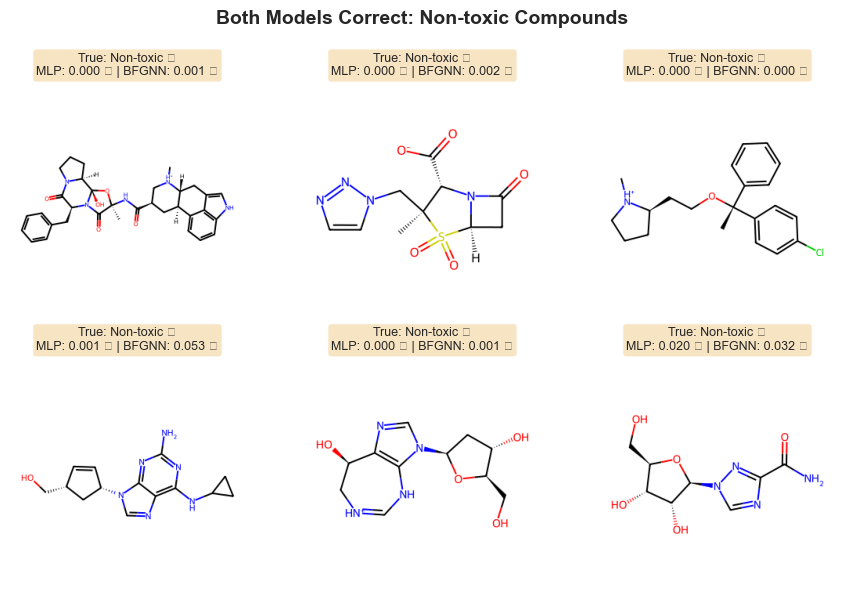


SAMPLES: Both Models Wrong - False Negatives (Missed Toxic)
✓ Saved to: /Users/nguyennghia/PROJECT/Torch_molecule/output/figures/05_samples_both_wrong_fn.png


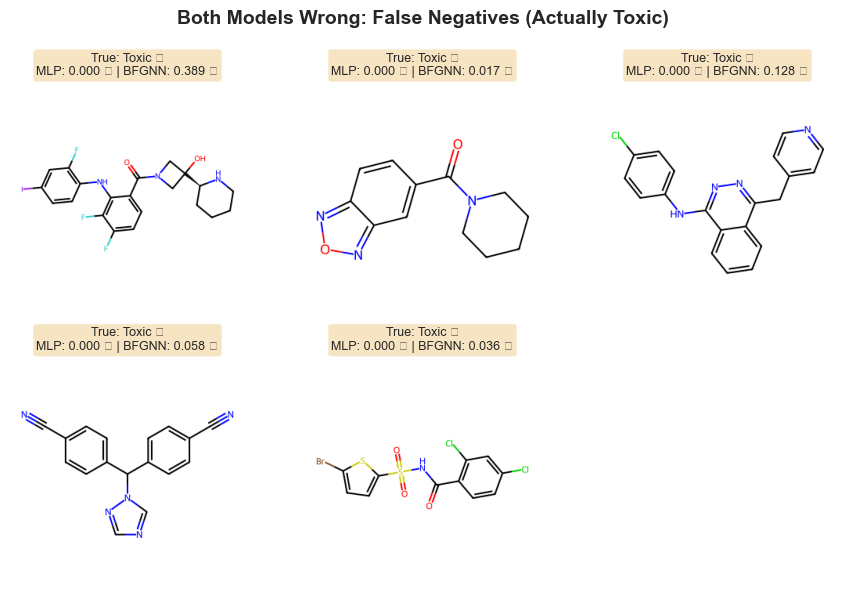


SAMPLES: Both Models Wrong - False Positives (Non-toxic Predicted as Toxic)
No examples found where both models incorrectly predicted non-toxic as toxic.

SAMPLES: Model Disagreement - MLP Correct, BFGNN Wrong
✓ Saved to: /Users/nguyennghia/PROJECT/Torch_molecule/output/figures/05_samples_mlp_correct_bfgnn_wrong.png


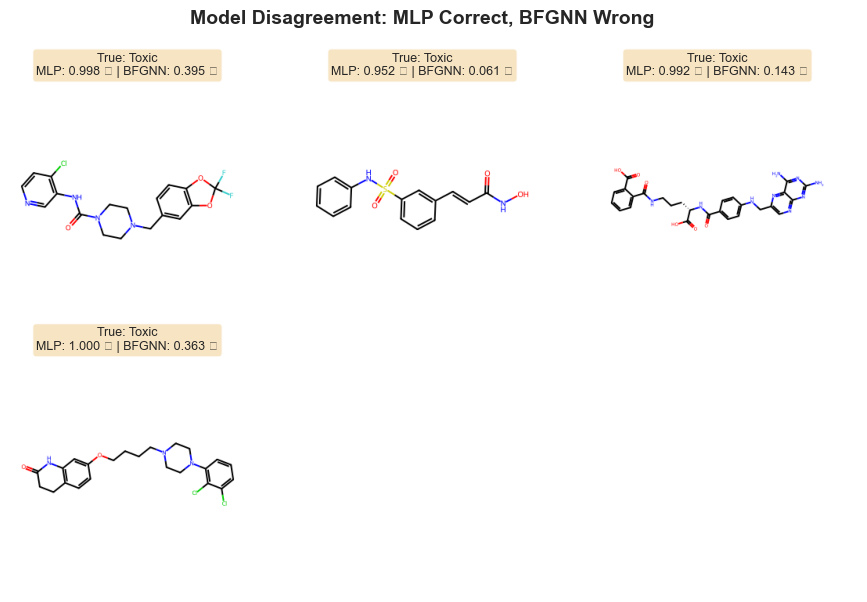


SAMPLES: Model Disagreement - BFGNN Correct, MLP Wrong
✓ Saved to: /Users/nguyennghia/PROJECT/Torch_molecule/output/figures/05_samples_bfgnn_correct_mlp_wrong.png


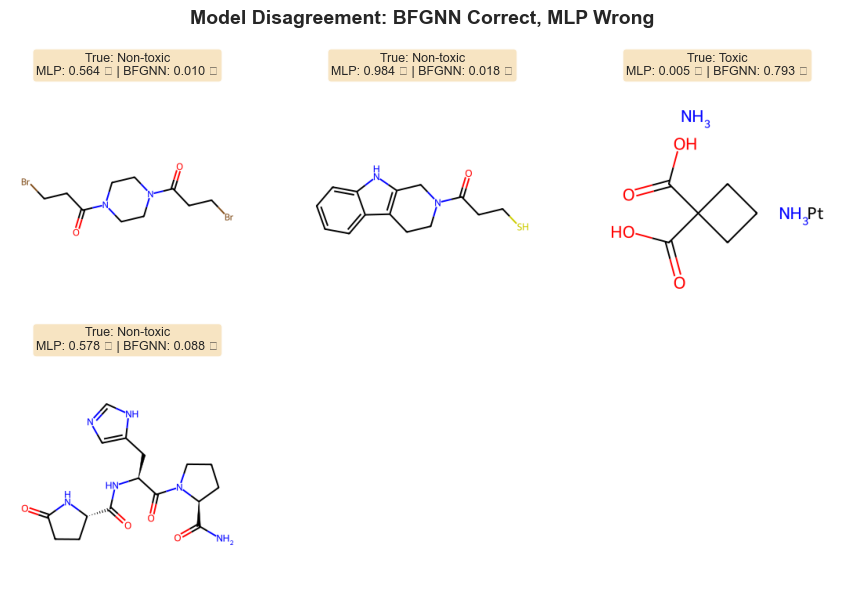


Sample Visualization Summary
Total samples analyzed: 148

MLP & BFGNN Comparison:
  Both correct: 135 (91.2%)
  Both wrong: 5 (3.4%)
  MLP only correct: 4 (2.7%)
  BFGNN only correct: 4 (2.7%)

MLP Accuracy: 139/148 (93.9%)
BFGNN Accuracy: 139/148 (93.9%)
GRIN Accuracy: 140/148 (94.6%)
SMILESTransformer Accuracy: 143/148 (96.6%)

All Three Models Comparison:
  All three correct: 134 (90.5%)
  All three wrong: 4 (2.7%)

All Four Models Comparison:
  All four correct: 132 (89.2%)
  All four wrong: 1 (0.7%)

MLP & GRIN Comparison:
  Both correct: 136 (91.9%)
  Both wrong: 5 (3.4%)
  MLP only correct: 3 (2.0%)
  GRIN only correct: 4 (2.7%)

BFGNN & GRIN Comparison:
  Both correct: 137 (92.6%)
  Both wrong: 6 (4.1%)
  BFGNN only correct: 2 (1.4%)
  GRIN only correct: 3 (2.0%)

SAMPLES: Model Disagreement - MLP Correct, GRIN Wrong
✓ Saved to: /Users/nguyennghia/PROJECT/Torch_molecule/output/figures/05_samples_mlp_correct_grin_wrong.png


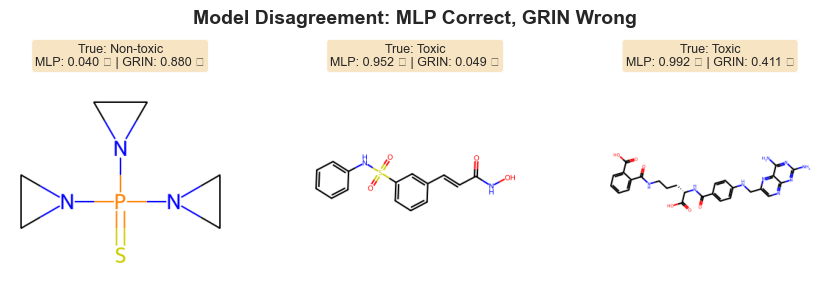


SAMPLES: Model Disagreement - GRIN Correct, MLP Wrong
✓ Saved to: /Users/nguyennghia/PROJECT/Torch_molecule/output/figures/05_samples_grin_correct_mlp_wrong.png


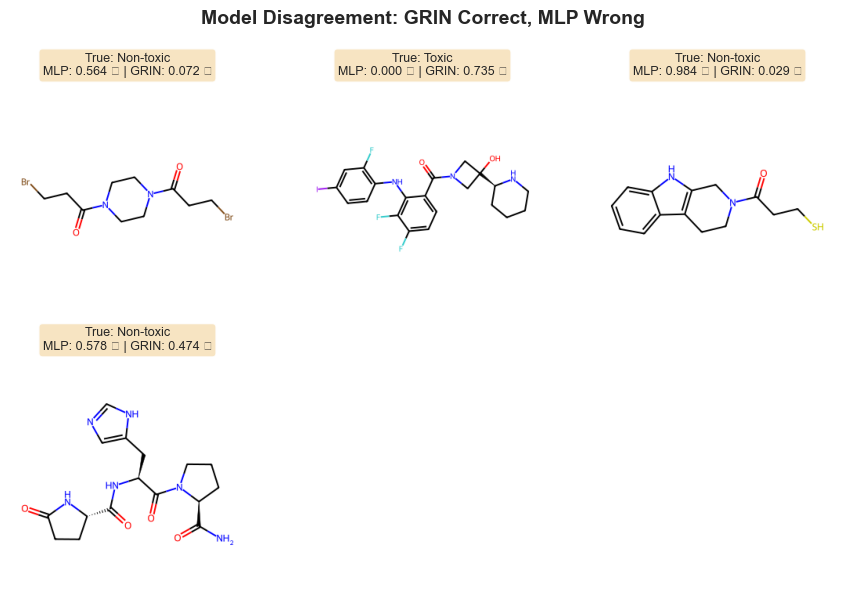


SAMPLES: Model Disagreement - BFGNN Correct, GRIN Wrong
✓ Saved to: /Users/nguyennghia/PROJECT/Torch_molecule/output/figures/05_samples_bfgnn_correct_grin_wrong.png


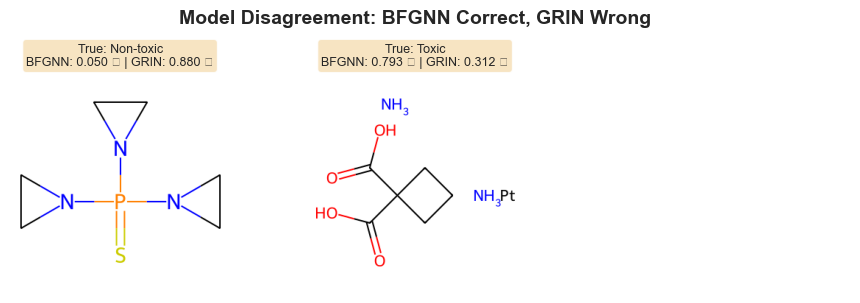


SAMPLES: Model Disagreement - GRIN Correct, BFGNN Wrong
✓ Saved to: /Users/nguyennghia/PROJECT/Torch_molecule/output/figures/05_samples_grin_correct_bfgnn_wrong.png


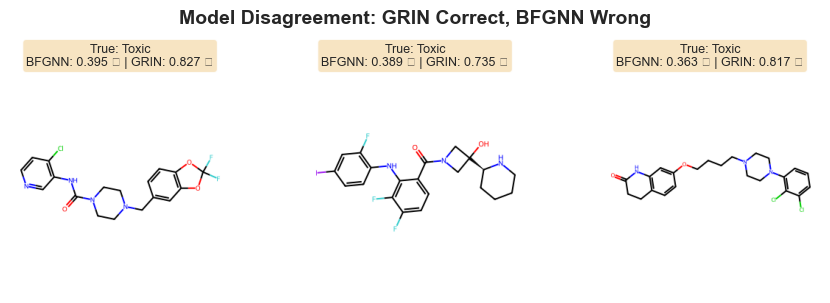

In [11]:
# Create comprehensive dataframe with all available predictions
from rdkit import Chem
from rdkit.Chem import Draw
from src.featurization import smiles_to_mol

# Start with base dataframe
results_df = pd.DataFrame({
    'smiles': test_df['smiles'].values,
    'true_label': test_labels,
})

# Add MLP predictions
if mlp_predictions is not None:
    mlp_pred_binary = (mlp_predictions > 0.5).astype(int)
    results_df['mlp_prob'] = mlp_predictions
    results_df['mlp_pred'] = mlp_pred_binary
    results_df['mlp_correct'] = (results_df['mlp_pred'] == results_df['true_label'])

# Add BFGNN predictions
if bfgnn_predictions is not None:
    bfgnn_pred_binary = (bfgnn_predictions > 0.5).astype(int)
    results_df['bfgnn_prob'] = bfgnn_predictions
    results_df['bfgnn_pred'] = bfgnn_pred_binary
    results_df['bfgnn_correct'] = (results_df['bfgnn_pred'] == results_df['true_label'])

# Add GRIN predictions
if grin_predictions is not None:
    grin_pred_binary = (grin_predictions > 0.5).astype(int)
    results_df['grin_prob'] = grin_predictions
    results_df['grin_pred'] = grin_pred_binary
    results_df['grin_correct'] = (results_df['grin_pred'] == results_df['true_label'])

# Add SMILESTransformer predictions
if smilestransformer_predictions is not None:
    smilestransformer_pred_binary = (smilestransformer_predictions > 0.5).astype(int)
    results_df['smilestransformer_prob'] = smilestransformer_predictions
    results_df['smilestransformer_pred'] = smilestransformer_pred_binary
    results_df['smilestransformer_correct'] = (results_df['smilestransformer_pred'] == results_df['true_label'])

# Calculate agreement columns for MLP and BFGNN (for backward compatibility)
if mlp_predictions is not None and bfgnn_predictions is not None:
    results_df['both_correct'] = results_df['mlp_correct'] & results_df['bfgnn_correct']
    results_df['both_wrong'] = ~results_df['mlp_correct'] & ~results_df['bfgnn_correct']
    results_df['mlp_only_correct'] = results_df['mlp_correct'] & ~results_df['bfgnn_correct']
    results_df['bfgnn_only_correct'] = ~results_df['mlp_correct'] & results_df['bfgnn_correct']

# Only proceed with visualization if we have at least MLP and BFGNN
if mlp_predictions is not None and bfgnn_predictions is not None:
    
    def visualize_molecule_grid(smiles_list, labels_list, n_cols=4, title_prefix=""):
        """Helper function to visualize molecules in a grid"""
        n_mols = len(smiles_list)
        if n_mols == 0:
            return
        
        n_rows = (n_mols + n_cols - 1) // n_cols
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
        
        if n_rows == 1:
            axes = axes.reshape(1, -1)
        axes = axes.flatten()
        
        for idx, (smiles, label) in enumerate(zip(smiles_list, labels_list)):
            mol = smiles_to_mol(smiles)
            if mol is None:
                axes[idx].text(0.5, 0.5, f'Invalid\nSMILES', 
                              ha='center', va='center', fontsize=10)
                axes[idx].axis('off')
                continue
            
            img = Draw.MolToImage(mol, size=(300, 300))
            axes[idx].imshow(img)
            axes[idx].axis('off')
            axes[idx].set_title(label, fontsize=9, pad=5, 
                               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        
        # Hide unused subplots
        for idx in range(n_mols, len(axes)):
            axes[idx].axis('off')
        
        plt.suptitle(title_prefix, fontsize=14, fontweight='bold', y=0.995)
        plt.tight_layout()
        return fig
    
    # 1. Both models correct - Toxic examples
    print("=" * 80)
    print("SAMPLES: Both Models Correct - Toxic Compounds")
    print("=" * 80)
    both_correct_toxic = results_df[results_df['both_correct'] & (results_df['true_label'] == 1)]
    if len(both_correct_toxic) > 0:
        sample_toxic = both_correct_toxic.head(6)
        labels_toxic = [
            f"True: Toxic ✓\nMLP: {row['mlp_prob']:.3f} ✓ | BFGNN: {row['bfgnn_prob']:.3f} ✓"
            for _, row in sample_toxic.iterrows()
        ]
        fig = visualize_molecule_grid(
            sample_toxic['smiles'].tolist(),
            labels_toxic,
            n_cols=3,
            title_prefix="Both Models Correct: Toxic Compounds"
        )
        plt.savefig(figures_dir / "05_samples_both_correct_toxic.png", dpi=300, bbox_inches='tight')
        print(f"✓ Saved to: {figures_dir / '05_samples_both_correct_toxic.png'}")
        plt.show()
    else:
        print("No examples found where both models correctly predicted toxic compounds.")
    
    # 2. Both models correct - Non-toxic examples
    print("\n" + "=" * 80)
    print("SAMPLES: Both Models Correct - Non-toxic Compounds")
    print("=" * 80)
    both_correct_nontoxic = results_df[results_df['both_correct'] & (results_df['true_label'] == 0)]
    if len(both_correct_nontoxic) > 0:
        sample_nontoxic = both_correct_nontoxic.head(6)
        labels_nontoxic = [
            f"True: Non-toxic ✓\nMLP: {row['mlp_prob']:.3f} ✓ | BFGNN: {row['bfgnn_prob']:.3f} ✓"
            for _, row in sample_nontoxic.iterrows()
        ]
        fig = visualize_molecule_grid(
            sample_nontoxic['smiles'].tolist(),
            labels_nontoxic,
            n_cols=3,
            title_prefix="Both Models Correct: Non-toxic Compounds"
        )
        plt.savefig(figures_dir / "05_samples_both_correct_nontoxic.png", dpi=300, bbox_inches='tight')
        print(f"✓ Saved to: {figures_dir / '05_samples_both_correct_nontoxic.png'}")
        plt.show()
    else:
        print("No examples found where both models correctly predicted non-toxic compounds.")
    
    # 3. Both models wrong - False negatives
    print("\n" + "=" * 80)
    print("SAMPLES: Both Models Wrong - False Negatives (Missed Toxic)")
    print("=" * 80)
    both_wrong_fn = results_df[results_df['both_wrong'] & (results_df['true_label'] == 1)]
    if len(both_wrong_fn) > 0:
        sample_fn = both_wrong_fn.head(6)
        labels_fn = [
            f"True: Toxic ✗\nMLP: {row['mlp_prob']:.3f} ✗ | BFGNN: {row['bfgnn_prob']:.3f} ✗"
            for _, row in sample_fn.iterrows()
        ]
        fig = visualize_molecule_grid(
            sample_fn['smiles'].tolist(),
            labels_fn,
            n_cols=3,
            title_prefix="Both Models Wrong: False Negatives (Actually Toxic)"
        )
        plt.savefig(figures_dir / "05_samples_both_wrong_fn.png", dpi=300, bbox_inches='tight')
        print(f"✓ Saved to: {figures_dir / '05_samples_both_wrong_fn.png'}")
        plt.show()
    else:
        print("No examples found where both models missed toxic compounds.")
    
    # 4. Both models wrong - False positives
    print("\n" + "=" * 80)
    print("SAMPLES: Both Models Wrong - False Positives (Non-toxic Predicted as Toxic)")
    print("=" * 80)
    both_wrong_fp = results_df[results_df['both_wrong'] & (results_df['true_label'] == 0)]
    if len(both_wrong_fp) > 0:
        sample_fp = both_wrong_fp.head(6)
        labels_fp = [
            f"True: Non-toxic ✗\nMLP: {row['mlp_prob']:.3f} ✗ | BFGNN: {row['bfgnn_prob']:.3f} ✗"
            for _, row in sample_fp.iterrows()
        ]
        fig = visualize_molecule_grid(
            sample_fp['smiles'].tolist(),
            labels_fp,
            n_cols=3,
            title_prefix="Both Models Wrong: False Positives (Actually Non-toxic)"
        )
        plt.savefig(figures_dir / "05_samples_both_wrong_fp.png", dpi=300, bbox_inches='tight')
        print(f"✓ Saved to: {figures_dir / '05_samples_both_wrong_fp.png'}")
        plt.show()
    else:
        print("No examples found where both models incorrectly predicted non-toxic as toxic.")
    
    # 5. Model disagreements - MLP correct, BFGNN wrong
    print("\n" + "=" * 80)
    print("SAMPLES: Model Disagreement - MLP Correct, BFGNN Wrong")
    print("=" * 80)
    mlp_only = results_df[results_df['mlp_only_correct']]
    if len(mlp_only) > 0:
        sample_mlp = mlp_only.head(6)
        labels_mlp = [
            f"True: {'Toxic' if row['true_label'] == 1 else 'Non-toxic'}\n"
            f"MLP: {row['mlp_prob']:.3f} ✓ | BFGNN: {row['bfgnn_prob']:.3f} ✗"
            for _, row in sample_mlp.iterrows()
        ]
        fig = visualize_molecule_grid(
            sample_mlp['smiles'].tolist(),
            labels_mlp,
            n_cols=3,
            title_prefix="Model Disagreement: MLP Correct, BFGNN Wrong"
        )
        plt.savefig(figures_dir / "05_samples_mlp_correct_bfgnn_wrong.png", dpi=300, bbox_inches='tight')
        print(f"✓ Saved to: {figures_dir / '05_samples_mlp_correct_bfgnn_wrong.png'}")
        plt.show()
    else:
        print("No examples found where MLP was correct and BFGNN was wrong.")
    
    # 6. Model disagreements - BFGNN correct, MLP wrong
    print("\n" + "=" * 80)
    print("SAMPLES: Model Disagreement - BFGNN Correct, MLP Wrong")
    print("=" * 80)
    bfgnn_only = results_df[results_df['bfgnn_only_correct']]
    if len(bfgnn_only) > 0:
        sample_bfgnn = bfgnn_only.head(6)
        labels_bfgnn = [
            f"True: {'Toxic' if row['true_label'] == 1 else 'Non-toxic'}\n"
            f"MLP: {row['mlp_prob']:.3f} ✗ | BFGNN: {row['bfgnn_prob']:.3f} ✓"
            for _, row in sample_bfgnn.iterrows()
        ]
        fig = visualize_molecule_grid(
            sample_bfgnn['smiles'].tolist(),
            labels_bfgnn,
            n_cols=3,
            title_prefix="Model Disagreement: BFGNN Correct, MLP Wrong"
        )
        plt.savefig(figures_dir / "05_samples_bfgnn_correct_mlp_wrong.png", dpi=300, bbox_inches='tight')
        print(f"✓ Saved to: {figures_dir / '05_samples_bfgnn_correct_mlp_wrong.png'}")
        plt.show()
    else:
        print("No examples found where BFGNN was correct and MLP was wrong.")
    
    print("\n" + "=" * 80)
    print("Sample Visualization Summary")
    print("=" * 80)
    print(f"Total samples analyzed: {len(results_df)}")
    
    # Summary for MLP and BFGNN
    if mlp_predictions is not None and bfgnn_predictions is not None:
        print(f"\nMLP & BFGNN Comparison:")
        print(f"  Both correct: {results_df['both_correct'].sum()} ({results_df['both_correct'].mean()*100:.1f}%)")
        print(f"  Both wrong: {results_df['both_wrong'].sum()} ({results_df['both_wrong'].mean()*100:.1f}%)")
        print(f"  MLP only correct: {results_df['mlp_only_correct'].sum()} ({results_df['mlp_only_correct'].mean()*100:.1f}%)")
        print(f"  BFGNN only correct: {results_df['bfgnn_only_correct'].sum()} ({results_df['bfgnn_only_correct'].mean()*100:.1f}%)")
    
    # Individual model accuracy
    if mlp_predictions is not None:
        print(f"\nMLP Accuracy: {results_df['mlp_correct'].sum()}/{len(results_df)} ({results_df['mlp_correct'].mean()*100:.1f}%)")
    if bfgnn_predictions is not None:
        print(f"BFGNN Accuracy: {results_df['bfgnn_correct'].sum()}/{len(results_df)} ({results_df['bfgnn_correct'].mean()*100:.1f}%)")
    if grin_predictions is not None:
        print(f"GRIN Accuracy: {results_df['grin_correct'].sum()}/{len(results_df)} ({results_df['grin_correct'].mean()*100:.1f}%)")
    if smilestransformer_predictions is not None:
        print(f"SMILESTransformer Accuracy: {results_df['smilestransformer_correct'].sum()}/{len(results_df)} ({results_df['smilestransformer_correct'].mean()*100:.1f}%)")
    
    # Three-way comparison if all three models available
    if mlp_predictions is not None and bfgnn_predictions is not None and grin_predictions is not None:
        all_three_correct = results_df['mlp_correct'] & results_df['bfgnn_correct'] & results_df['grin_correct']
        all_three_wrong = ~results_df['mlp_correct'] & ~results_df['bfgnn_correct'] & ~results_df['grin_correct']
        print(f"\nAll Three Models Comparison:")
        print(f"  All three correct: {all_three_correct.sum()} ({all_three_correct.mean()*100:.1f}%)")
        print(f"  All three wrong: {all_three_wrong.sum()} ({all_three_wrong.mean()*100:.1f}%)")
    
    # Four-way comparison if all four models available
    if (mlp_predictions is not None and bfgnn_predictions is not None and 
        grin_predictions is not None and smilestransformer_predictions is not None):
        all_four_correct = (results_df['mlp_correct'] & results_df['bfgnn_correct'] & 
                           results_df['grin_correct'] & results_df['smilestransformer_correct'])
        all_four_wrong = (~results_df['mlp_correct'] & ~results_df['bfgnn_correct'] & 
                         ~results_df['grin_correct'] & ~results_df['smilestransformer_correct'])
        print(f"\nAll Four Models Comparison:")
        print(f"  All four correct: {all_four_correct.sum()} ({all_four_correct.mean()*100:.1f}%)")
        print(f"  All four wrong: {all_four_wrong.sum()} ({all_four_wrong.mean()*100:.1f}%)")
        
        # Pairwise with GRIN
        mlp_grin_both = results_df['mlp_correct'] & results_df['grin_correct']
        mlp_grin_both_wrong = ~results_df['mlp_correct'] & ~results_df['grin_correct']
        mlp_only_grin = results_df['mlp_correct'] & ~results_df['grin_correct']
        grin_only_mlp = ~results_df['mlp_correct'] & results_df['grin_correct']
        
        bfgnn_grin_both = results_df['bfgnn_correct'] & results_df['grin_correct']
        bfgnn_grin_both_wrong = ~results_df['bfgnn_correct'] & ~results_df['grin_correct']
        bfgnn_only_grin = results_df['bfgnn_correct'] & ~results_df['grin_correct']
        grin_only_bfgnn = ~results_df['bfgnn_correct'] & results_df['grin_correct']
        
        print(f"\nMLP & GRIN Comparison:")
        print(f"  Both correct: {mlp_grin_both.sum()} ({mlp_grin_both.mean()*100:.1f}%)")
        print(f"  Both wrong: {mlp_grin_both_wrong.sum()} ({mlp_grin_both_wrong.mean()*100:.1f}%)")
        print(f"  MLP only correct: {mlp_only_grin.sum()} ({mlp_only_grin.mean()*100:.1f}%)")
        print(f"  GRIN only correct: {grin_only_mlp.sum()} ({grin_only_mlp.mean()*100:.1f}%)")
        
        print(f"\nBFGNN & GRIN Comparison:")
        print(f"  Both correct: {bfgnn_grin_both.sum()} ({bfgnn_grin_both.mean()*100:.1f}%)")
        print(f"  Both wrong: {bfgnn_grin_both_wrong.sum()} ({bfgnn_grin_both_wrong.mean()*100:.1f}%)")
        print(f"  BFGNN only correct: {bfgnn_only_grin.sum()} ({bfgnn_only_grin.mean()*100:.1f}%)")
        print(f"  GRIN only correct: {grin_only_bfgnn.sum()} ({grin_only_bfgnn.mean()*100:.1f}%)")
    
    # Add GRIN sample visualizations if available
    if grin_predictions is not None and mlp_predictions is not None:
        # 7. Model disagreements - MLP correct, GRIN wrong
        print("\n" + "=" * 80)
        print("SAMPLES: Model Disagreement - MLP Correct, GRIN Wrong")
        print("=" * 80)
        mlp_only_grin_samples = results_df[results_df['mlp_correct'] & ~results_df['grin_correct']]
        if len(mlp_only_grin_samples) > 0:
            sample_mlp_grin = mlp_only_grin_samples.head(6)
            labels_mlp_grin = [
                f"True: {'Toxic' if row['true_label'] == 1 else 'Non-toxic'}\n"
                f"MLP: {row['mlp_prob']:.3f} ✓ | GRIN: {row['grin_prob']:.3f} ✗"
                for _, row in sample_mlp_grin.iterrows()
            ]
            fig = visualize_molecule_grid(
                sample_mlp_grin['smiles'].tolist(),
                labels_mlp_grin,
                n_cols=3,
                title_prefix="Model Disagreement: MLP Correct, GRIN Wrong"
            )
            plt.savefig(figures_dir / "05_samples_mlp_correct_grin_wrong.png", dpi=300, bbox_inches='tight')
            print(f"✓ Saved to: {figures_dir / '05_samples_mlp_correct_grin_wrong.png'}")
            plt.show()
        else:
            print("No examples found where MLP was correct and GRIN was wrong.")
        
        # 8. Model disagreements - GRIN correct, MLP wrong
        print("\n" + "=" * 80)
        print("SAMPLES: Model Disagreement - GRIN Correct, MLP Wrong")
        print("=" * 80)
        grin_only_mlp_samples = results_df[~results_df['mlp_correct'] & results_df['grin_correct']]
        if len(grin_only_mlp_samples) > 0:
            sample_grin_mlp = grin_only_mlp_samples.head(6)
            labels_grin_mlp = [
                f"True: {'Toxic' if row['true_label'] == 1 else 'Non-toxic'}\n"
                f"MLP: {row['mlp_prob']:.3f} ✗ | GRIN: {row['grin_prob']:.3f} ✓"
                for _, row in sample_grin_mlp.iterrows()
            ]
            fig = visualize_molecule_grid(
                sample_grin_mlp['smiles'].tolist(),
                labels_grin_mlp,
                n_cols=3,
                title_prefix="Model Disagreement: GRIN Correct, MLP Wrong"
            )
            plt.savefig(figures_dir / "05_samples_grin_correct_mlp_wrong.png", dpi=300, bbox_inches='tight')
            print(f"✓ Saved to: {figures_dir / '05_samples_grin_correct_mlp_wrong.png'}")
            plt.show()
        else:
            print("No examples found where GRIN was correct and MLP was wrong.")
    
    if grin_predictions is not None and bfgnn_predictions is not None:
        # 9. Model disagreements - BFGNN correct, GRIN wrong
        print("\n" + "=" * 80)
        print("SAMPLES: Model Disagreement - BFGNN Correct, GRIN Wrong")
        print("=" * 80)
        bfgnn_only_grin_samples = results_df[results_df['bfgnn_correct'] & ~results_df['grin_correct']]
        if len(bfgnn_only_grin_samples) > 0:
            sample_bfgnn_grin = bfgnn_only_grin_samples.head(6)
            labels_bfgnn_grin = [
                f"True: {'Toxic' if row['true_label'] == 1 else 'Non-toxic'}\n"
                f"BFGNN: {row['bfgnn_prob']:.3f} ✓ | GRIN: {row['grin_prob']:.3f} ✗"
                for _, row in sample_bfgnn_grin.iterrows()
            ]
            fig = visualize_molecule_grid(
                sample_bfgnn_grin['smiles'].tolist(),
                labels_bfgnn_grin,
                n_cols=3,
                title_prefix="Model Disagreement: BFGNN Correct, GRIN Wrong"
            )
            plt.savefig(figures_dir / "05_samples_bfgnn_correct_grin_wrong.png", dpi=300, bbox_inches='tight')
            print(f"✓ Saved to: {figures_dir / '05_samples_bfgnn_correct_grin_wrong.png'}")
            plt.show()
        else:
            print("No examples found where BFGNN was correct and GRIN was wrong.")
        
        # 10. Model disagreements - GRIN correct, BFGNN wrong
        print("\n" + "=" * 80)
        print("SAMPLES: Model Disagreement - GRIN Correct, BFGNN Wrong")
        print("=" * 80)
        grin_only_bfgnn_samples = results_df[~results_df['bfgnn_correct'] & results_df['grin_correct']]
        if len(grin_only_bfgnn_samples) > 0:
            sample_grin_bfgnn = grin_only_bfgnn_samples.head(6)
            labels_grin_bfgnn = [
                f"True: {'Toxic' if row['true_label'] == 1 else 'Non-toxic'}\n"
                f"BFGNN: {row['bfgnn_prob']:.3f} ✗ | GRIN: {row['grin_prob']:.3f} ✓"
                for _, row in sample_grin_bfgnn.iterrows()
            ]
            fig = visualize_molecule_grid(
                sample_grin_bfgnn['smiles'].tolist(),
                labels_grin_bfgnn,
                n_cols=3,
                title_prefix="Model Disagreement: GRIN Correct, BFGNN Wrong"
            )
            plt.savefig(figures_dir / "05_samples_grin_correct_bfgnn_wrong.png", dpi=300, bbox_inches='tight')
            print(f"✓ Saved to: {figures_dir / '05_samples_grin_correct_bfgnn_wrong.png'}")
            plt.show()
        else:
            print("No examples found where GRIN was correct and BFGNN was wrong.")

else:
    print("⚠ At least MLP and BFGNN models needed for sample visualization")


## Error Analysis

Analyze misclassified examples from both Baseline MLP and torch-molecule GNN models to understand model limitations and compare error patterns.



In [12]:
# Load test data
cache_dir = project_root / "data"
train_df, val_df, test_df = load_clintox_dataset(cache_dir=str(cache_dir), split_type="scaffold", seed=42)

print("=" * 80)
print("ERROR ANALYSIS: Baseline MLP Model")
print("=" * 80)

# Baseline MLP error analysis
model_path = models_dir / "baseline_mlp_model.pt"
mlp_misclassified = None

if model_path.exists():
    # Load model using pipeline function
    model = load_mlp_model(model_path, config)
    
    # Get predictions
    test_fps = featurize_batch(
        test_df['smiles'].tolist(),
        mode="fingerprint",
        radius=config['featurization']['fingerprint']['radius'],
        n_bits=config['featurization']['fingerprint']['n_bits']
    )
    
    with torch.no_grad():
        test_tensors = torch.FloatTensor(test_fps)
        logits = model(test_tensors)
        probs = torch.sigmoid(logits).numpy().flatten()
        preds = (probs > 0.5).astype(int)
    
    test_df_mlp = test_df.copy()
    test_df_mlp['predicted_prob_mlp'] = probs
    test_df_mlp['predicted_label_mlp'] = preds
    test_df_mlp['correct_mlp'] = (test_df_mlp['CT_TOX'] == test_df_mlp['predicted_label_mlp'])
    
    # Error analysis
    mlp_misclassified = test_df_mlp[test_df_mlp['correct_mlp'] == False]
    
    print(f"\nTotal test samples: {len(test_df_mlp)}")
    print(f"Misclassified: {len(mlp_misclassified)} ({len(mlp_misclassified)/len(test_df_mlp)*100:.2f}%)")
    
    if len(mlp_misclassified) > 0:
        print("\nMisclassification patterns:")
        fp_mlp = len(mlp_misclassified[(mlp_misclassified['CT_TOX']==0) & (mlp_misclassified['predicted_label_mlp']==1)])
        fn_mlp = len(mlp_misclassified[(mlp_misclassified['CT_TOX']==1) & (mlp_misclassified['predicted_label_mlp']==0)])
        print(f"  False Positives (predicted toxic, actually non-toxic): {fp_mlp}")
        print(f"  False Negatives (predicted non-toxic, actually toxic): {fn_mlp}")
        
        # Show some misclassified examples
        print("\nSample misclassified molecules (Baseline MLP):")
        print(mlp_misclassified[['smiles', 'CT_TOX', 'predicted_label_mlp', 'predicted_prob_mlp']].head(10))
else:
    print("⚠ Baseline MLP model not found. Please train the model first (notebook 02).")

# Torch-molecule GNN error analysis
print("\n" + "=" * 80)
print("ERROR ANALYSIS: torch-molecule GNN Model")
print("=" * 80)

import pickle
gnn_misclassified = None
torch_molecule_model = None

# Try to load torch-molecule model
torch_molecule_model_path = models_dir / "torch_molecule_model.pt"
if torch_molecule_model_path.exists():
    try:
        from torch_molecule import BFGNNMolecularPredictor
        torch_molecule_model = BFGNNMolecularPredictor()
        try:
            torch_molecule_model.load_model(str(torch_molecule_model_path))
        except:
            with open(torch_molecule_model_path, 'rb') as f:
                torch_molecule_model = pickle.load(f)
    except Exception as e:
        print(f"⚠ Could not load torch-molecule model: {e}")

# Try pickle format
if torch_molecule_model is None:
    pickle_path = models_dir / "torch_molecule_model.pkl"
    if pickle_path.exists():
        try:
            with open(pickle_path, 'rb') as f:
                torch_molecule_model = pickle.load(f)
        except Exception as e:
            print(f"⚠ Could not load torch-molecule model from pickle: {e}")

if torch_molecule_model is not None:
    from src.train import predict_with_torch_molecule_model
    
    # Get predictions
    X_test = test_df['smiles'].tolist()
    test_probs_gnn = predict_with_torch_molecule_model(torch_molecule_model, X_test)
    test_preds_gnn = (test_probs_gnn > 0.5).astype(int)
    
    # Store predictions for use in other cells
    bfgnn_predictions = test_probs_gnn
    
    test_df_gnn = test_df.copy()
    test_df_gnn['predicted_prob_gnn'] = test_probs_gnn
    test_df_gnn['predicted_label_gnn'] = test_preds_gnn
    test_df_gnn['correct_gnn'] = (test_df_gnn['CT_TOX'] == test_df_gnn['predicted_label_gnn'])
    
    # Error analysis
    gnn_misclassified = test_df_gnn[test_df_gnn['correct_gnn'] == False]
    
    print(f"\nTotal test samples: {len(test_df_gnn)}")
    print(f"Misclassified: {len(gnn_misclassified)} ({len(gnn_misclassified)/len(test_df_gnn)*100:.2f}%)")
    
    if len(gnn_misclassified) > 0:
        print("\nMisclassification patterns:")
        fp_gnn = len(gnn_misclassified[(gnn_misclassified['CT_TOX']==0) & (gnn_misclassified['predicted_label_gnn']==1)])
        fn_gnn = len(gnn_misclassified[(gnn_misclassified['CT_TOX']==1) & (gnn_misclassified['predicted_label_gnn']==0)])
        print(f"  False Positives (predicted toxic, actually non-toxic): {fp_gnn}")
        print(f"  False Negatives (predicted non-toxic, actually toxic): {fn_gnn}")
        
        # Show some misclassified examples
        print("\nSample misclassified molecules (GNN):")
        print(gnn_misclassified[['smiles', 'CT_TOX', 'predicted_label_gnn', 'predicted_prob_gnn']].head(10))
else:
    print("⚠ torch-molecule GNN (BFGNN) model not found. Please train the model first (notebook 03).")
    bfgnn_predictions = None

# GRIN error analysis
print("\n" + "=" * 80)
print("ERROR ANALYSIS: GRIN Model")
print("=" * 80)

grin_misclassified = None
grin_model = None

# Try to load GRIN model
grin_model_path = models_dir / "grin_model.pt"
if grin_model_path.exists():
    try:
        grin_model = load_gnn_model(grin_model_path, model_type="GRIN")
    except Exception as e:
        print(f"⚠ Could not load GRIN model: {e}")

# Try pickle format
if grin_model is None:
    grin_pickle_path = models_dir / "grin_model.pkl"
    if grin_pickle_path.exists():
        try:
            with open(grin_pickle_path, 'rb') as f:
                grin_model = pickle.load(f)
        except Exception as e:
            print(f"⚠ Could not load GRIN model from pickle: {e}")

if grin_model is not None:
    # Get predictions
    X_test = test_df['smiles'].tolist()
    test_probs_grin = predict_with_torch_molecule_model(grin_model, X_test)
    test_preds_grin = (test_probs_grin > 0.5).astype(int)
    
    # Store predictions for use in other cells
    grin_predictions = test_probs_grin
    
    test_df_grin = test_df.copy()
    test_df_grin['predicted_prob_grin'] = test_probs_grin
    test_df_grin['predicted_label_grin'] = test_preds_grin
    test_df_grin['correct_grin'] = (test_df_grin['CT_TOX'] == test_df_grin['predicted_label_grin'])
    
    # Error analysis
    grin_misclassified = test_df_grin[test_df_grin['correct_grin'] == False]
    
    print(f"\nTotal test samples: {len(test_df_grin)}")
    print(f"Misclassified: {len(grin_misclassified)} ({len(grin_misclassified)/len(test_df_grin)*100:.2f}%)")
    
    if len(grin_misclassified) > 0:
        print("\nMisclassification patterns:")
        fp_grin = len(grin_misclassified[(grin_misclassified['CT_TOX']==0) & (grin_misclassified['predicted_label_grin']==1)])
        fn_grin = len(grin_misclassified[(grin_misclassified['CT_TOX']==1) & (grin_misclassified['predicted_label_grin']==0)])
        print(f"  False Positives (predicted toxic, actually non-toxic): {fp_grin}")
        print(f"  False Negatives (predicted non-toxic, actually toxic): {fn_grin}")
        
        # Show some misclassified examples
        print("\nSample misclassified molecules (GRIN):")
        print(grin_misclassified[['smiles', 'CT_TOX', 'predicted_label_grin', 'predicted_prob_grin']].head(10))
else:
    print("⚠ GRIN model not found. Please train the model first (notebook 03_training_grin).")
    grin_predictions = None

# Compare error patterns
print("\n" + "=" * 80)
print("ERROR PATTERN COMPARISON")
print("=" * 80)

# Compare error patterns across all available models
models_available = []
if mlp_misclassified is not None:
    models_available.append(('MLP', mlp_misclassified))
if gnn_misclassified is not None:
    models_available.append(('BFGNN', gnn_misclassified))
if grin_misclassified is not None:
    models_available.append(('GRIN', grin_misclassified))

if len(models_available) >= 2:
    model_names = [m[0] for m in models_available]
    misclassified_sets = {name: set(mis['smiles'].tolist()) for name, mis in models_available}
    
    print(f"\nError Pattern Comparison ({', '.join(model_names)}):")
    
    if len(models_available) == 2:
        # Two models
        name1, name2 = model_names
        set1, set2 = misclassified_sets[name1], misclassified_sets[name2]
        common = set1.intersection(set2)
        only1 = set1 - set2
        only2 = set2 - set1
        
        print(f"\nCommon misclassifications ({name1} & {name2}): {len(common)}")
        print(f"{name1}-only misclassifications: {len(only1)}")
        print(f"{name2}-only misclassifications: {len(only2)}")
    elif len(models_available) == 3:
        # All three models
        mlp_set = misclassified_sets.get('MLP', set())
        bfgnn_set = misclassified_sets.get('BFGNN', set())
        grin_set = misclassified_sets.get('GRIN', set())
        
        all_common = mlp_set & bfgnn_set & grin_set
        mlp_bfgnn_only = (mlp_set & bfgnn_set) - grin_set
        mlp_grin_only = (mlp_set & grin_set) - bfgnn_set
        bfgnn_grin_only = (bfgnn_set & grin_set) - mlp_set
        mlp_only = mlp_set - bfgnn_set - grin_set
        bfgnn_only = bfgnn_set - mlp_set - grin_set
        grin_only = grin_set - mlp_set - bfgnn_set
        
        print(f"\nCommon to all three models: {len(all_common)}")
        print(f"MLP & BFGNN only (not GRIN): {len(mlp_bfgnn_only)}")
        print(f"MLP & GRIN only (not BFGNN): {len(mlp_grin_only)}")
        print(f"BFGNN & GRIN only (not MLP): {len(bfgnn_grin_only)}")
        print(f"MLP-only: {len(mlp_only)}")
        print(f"BFGNN-only: {len(bfgnn_only)}")
        print(f"GRIN-only: {len(grin_only)}")
        
        print(f"\nThese patterns suggest:")
        print(f"  - {len(all_common)} molecules are consistently difficult for all three models")
        print(f"  - {len(mlp_only)} molecules are challenging only for MLP")
        print(f"  - {len(bfgnn_only)} molecules are challenging only for BFGNN")
        print(f"  - {len(grin_only)} molecules are challenging only for GRIN")
        print(f"  - Pairwise overlaps indicate complementary failure modes")
elif len(models_available) == 1:
    print(f"\n⚠ Only {models_available[0][0]} model available for error analysis")
else:
    print("\n⚠ No models available for error analysis")



ERROR ANALYSIS: Baseline MLP Model

Total test samples: 148
Misclassified: 9 (6.08%)

Misclassification patterns:
  False Positives (predicted toxic, actually non-toxic): 3
  False Negatives (predicted non-toxic, actually toxic): 6

Sample misclassified molecules (Baseline MLP):
                                                smiles  CT_TOX  \
10                        C1CN(CCN1C(=O)CCBr)C(=O)CCBr     0.0   
14   C1CCN[C@@H](C1)C2(CN(C2)C(=O)C3=C(C(=C(C=C3)F)...     1.0   
16                    C1CCN(CC1)C(=O)C2=CC3=NON=C3C=C2     1.0   
28                c1ccc2c(c1)c3c([nH]2)CN(CC3)C(=O)CCS     0.0   
35   C1=CC=C2C(=C1)C(=NN=C2NC3=CC=C(C=C3)Cl)CC4=CC=...     1.0   
100       C1=CC(=CC=C1C#N)C(C2=CC=C(C=C2)C#N)N3C=NC=N3     1.0   
104                    C1CC(C1)(C(=O)O)C(=O)O.N.N.[Pt]     1.0   
108    C1=CC(=C(C=C1Cl)Cl)C(=O)NS(=O)(=O)C2=CC=C(S2)Br     1.0   
130  c1c([nH]cn1)C[C@@H](C(=O)N2CCC[C@H]2C(=O)N)NC(...     0.0   

     predicted_label_mlp  predicted_prob_mlp  
10          

Predicting: 100%|██████████| 5/5 [00:00<00:00, 141.10it/s]



Total test samples: 148
Misclassified: 9 (6.08%)

Misclassification patterns:
  False Positives (predicted toxic, actually non-toxic): 0
  False Negatives (predicted non-toxic, actually toxic): 9

Sample misclassified molecules (GNN):
                                                smiles  CT_TOX  \
9    C1CN(CCN1CC2=CC3=C(C=C2)OC(O3)(F)F)C(=O)NC4=C(...     1.0   
14   C1CCN[C@@H](C1)C2(CN(C2)C(=O)C3=C(C(=C(C=C3)F)...     1.0   
16                    C1CCN(CC1)C(=O)C2=CC3=NON=C3C=C2     1.0   
35   C1=CC=C2C(=C1)C(=NN=C2NC3=CC=C(C=C3)Cl)CC4=CC=...     1.0   
45    C1=CC=C(C=C1)NS(=O)(=O)C2=CC=CC(=C2)/C=C/C(=O)NO     1.0   
74   C1=CC=C(C(=C1)C(=O)NCCC[C@@H](C(=O)O)NC(=O)C2=...     1.0   
89   C1CC(=O)NC2=C1C=CC(=C2)OCCCCN3CCN(CC3)C4=C(C(=...     1.0   
100       C1=CC(=CC=C1C#N)C(C2=CC=C(C=C2)C#N)N3C=NC=N3     1.0   
108    C1=CC(=C(C=C1Cl)Cl)C(=O)NS(=O)(=O)C2=CC=C(S2)Br     1.0   

     predicted_label_gnn  predicted_prob_gnn  
9                      0            0.394522  
14       

Predicting: 100%|██████████| 5/5 [00:00<00:00, 57.45it/s]


Total test samples: 148
Misclassified: 8 (5.41%)

Misclassification patterns:
  False Positives (predicted toxic, actually non-toxic): 1
  False Negatives (predicted non-toxic, actually toxic): 7

Sample misclassified molecules (GRIN):
                                                smiles  CT_TOX  \
8                               C1CN1P(=S)(N2CC2)N3CC3     0.0   
16                    C1CCN(CC1)C(=O)C2=CC3=NON=C3C=C2     1.0   
35   C1=CC=C2C(=C1)C(=NN=C2NC3=CC=C(C=C3)Cl)CC4=CC=...     1.0   
45    C1=CC=C(C=C1)NS(=O)(=O)C2=CC=CC(=C2)/C=C/C(=O)NO     1.0   
74   C1=CC=C(C(=C1)C(=O)NCCC[C@@H](C(=O)O)NC(=O)C2=...     1.0   
100       C1=CC(=CC=C1C#N)C(C2=CC=C(C=C2)C#N)N3C=NC=N3     1.0   
104                    C1CC(C1)(C(=O)O)C(=O)O.N.N.[Pt]     1.0   
108    C1=CC(=C(C=C1Cl)Cl)C(=O)NS(=O)(=O)C2=CC=C(S2)Br     1.0   

     predicted_label_grin  predicted_prob_grin  
8                       1             0.880156  
16                      0             0.137812  
35                   

## Embedding Visualization

Visualize learned embeddings from both Baseline MLP and torch-molecule GNN models using t-SNE or UMAP, colored by toxicity labels.

This section shows:
1. **MLP Embeddings**: Feature representations from the fingerprint-based model
2. **GNN Embeddings**: Graph-level representations from the GNN model (if available)



Embedding shape: (148, 128)
Computing 2D projection...


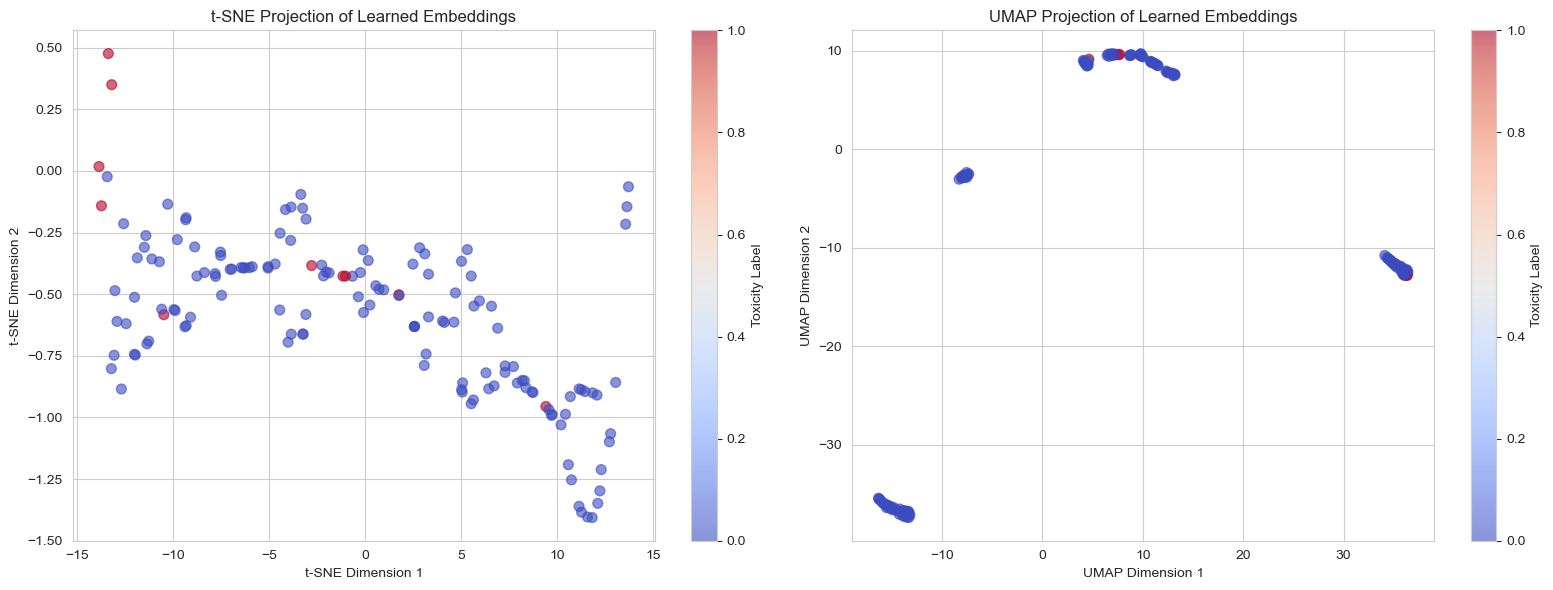

In [13]:
if model_path.exists() and 'test_df' in locals():
    # Extract embeddings from the model (last hidden layer before output)
    # For baseline MLP, we can use the features layer output
    model.eval()
    with torch.no_grad():
        # Get embeddings from the feature layer (before final output)
        embeddings = []
        for i in range(0, len(test_fps), 100):  # Process in batches
            batch = test_fps[i:i+100]
            batch_tensor = torch.FloatTensor(batch)
            # Get output from features layer
            features = model.features(batch_tensor)
            embeddings.append(features.numpy())
        embeddings = np.vstack(embeddings)
    
    print(f"Embedding shape: {embeddings.shape}")
    print("Computing 2D projection...")
    
    # t-SNE projection
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    embeddings_2d_tsne = tsne.fit_transform(embeddings)
    
    # UMAP projection if available
    if UMAP_AVAILABLE:
        reducer = umap.UMAP(n_components=2, random_state=42)
        embeddings_2d_umap = reducer.fit_transform(embeddings)
    
    # Visualize
    fig, axes = plt.subplots(1, 2 if UMAP_AVAILABLE else 1, figsize=(16, 6))
    if not UMAP_AVAILABLE:
        axes = [axes]
    
    # t-SNE plot
    scatter1 = axes[0].scatter(
        embeddings_2d_tsne[:, 0],
        embeddings_2d_tsne[:, 1],
        c=test_df['CT_TOX'].values,
        cmap='coolwarm',
        alpha=0.6,
        s=50
    )
    axes[0].set_title('t-SNE Projection of Learned Embeddings')
    axes[0].set_xlabel('t-SNE Dimension 1')
    axes[0].set_ylabel('t-SNE Dimension 2')
    plt.colorbar(scatter1, ax=axes[0], label='Toxicity Label')
    
    # UMAP plot
    if UMAP_AVAILABLE:
        scatter2 = axes[1].scatter(
            embeddings_2d_umap[:, 0],
            embeddings_2d_umap[:, 1],
            c=test_df['CT_TOX'].values,
            cmap='coolwarm',
            alpha=0.6,
            s=50
        )
        axes[1].set_title('UMAP Projection of Learned Embeddings')
        axes[1].set_xlabel('UMAP Dimension 1')
        axes[1].set_ylabel('UMAP Dimension 2')
        plt.colorbar(scatter2, ax=axes[1], label='Toxicity Label')
    
    plt.tight_layout()
    plt.show()



## GNN Molecular Graph Structure Visualization

Visualize molecular structures as graphs (nodes=atoms, edges=bonds) to understand how the GNN processes molecular information.
The GNN sees molecules as graphs where atoms are nodes and bonds are edges, enabling it to learn spatial and structural patterns.


GNN Molecular Graph Structure Visualization
Visualizing molecular structures as graphs (nodes=atoms, edges=bonds)
to understand how the GNN processes molecular information.

✓ GRIN molecular graph visualization saved to: /Users/nguyennghia/PROJECT/Torch_molecule/output/figures/05_grin_molecular_graphs.png


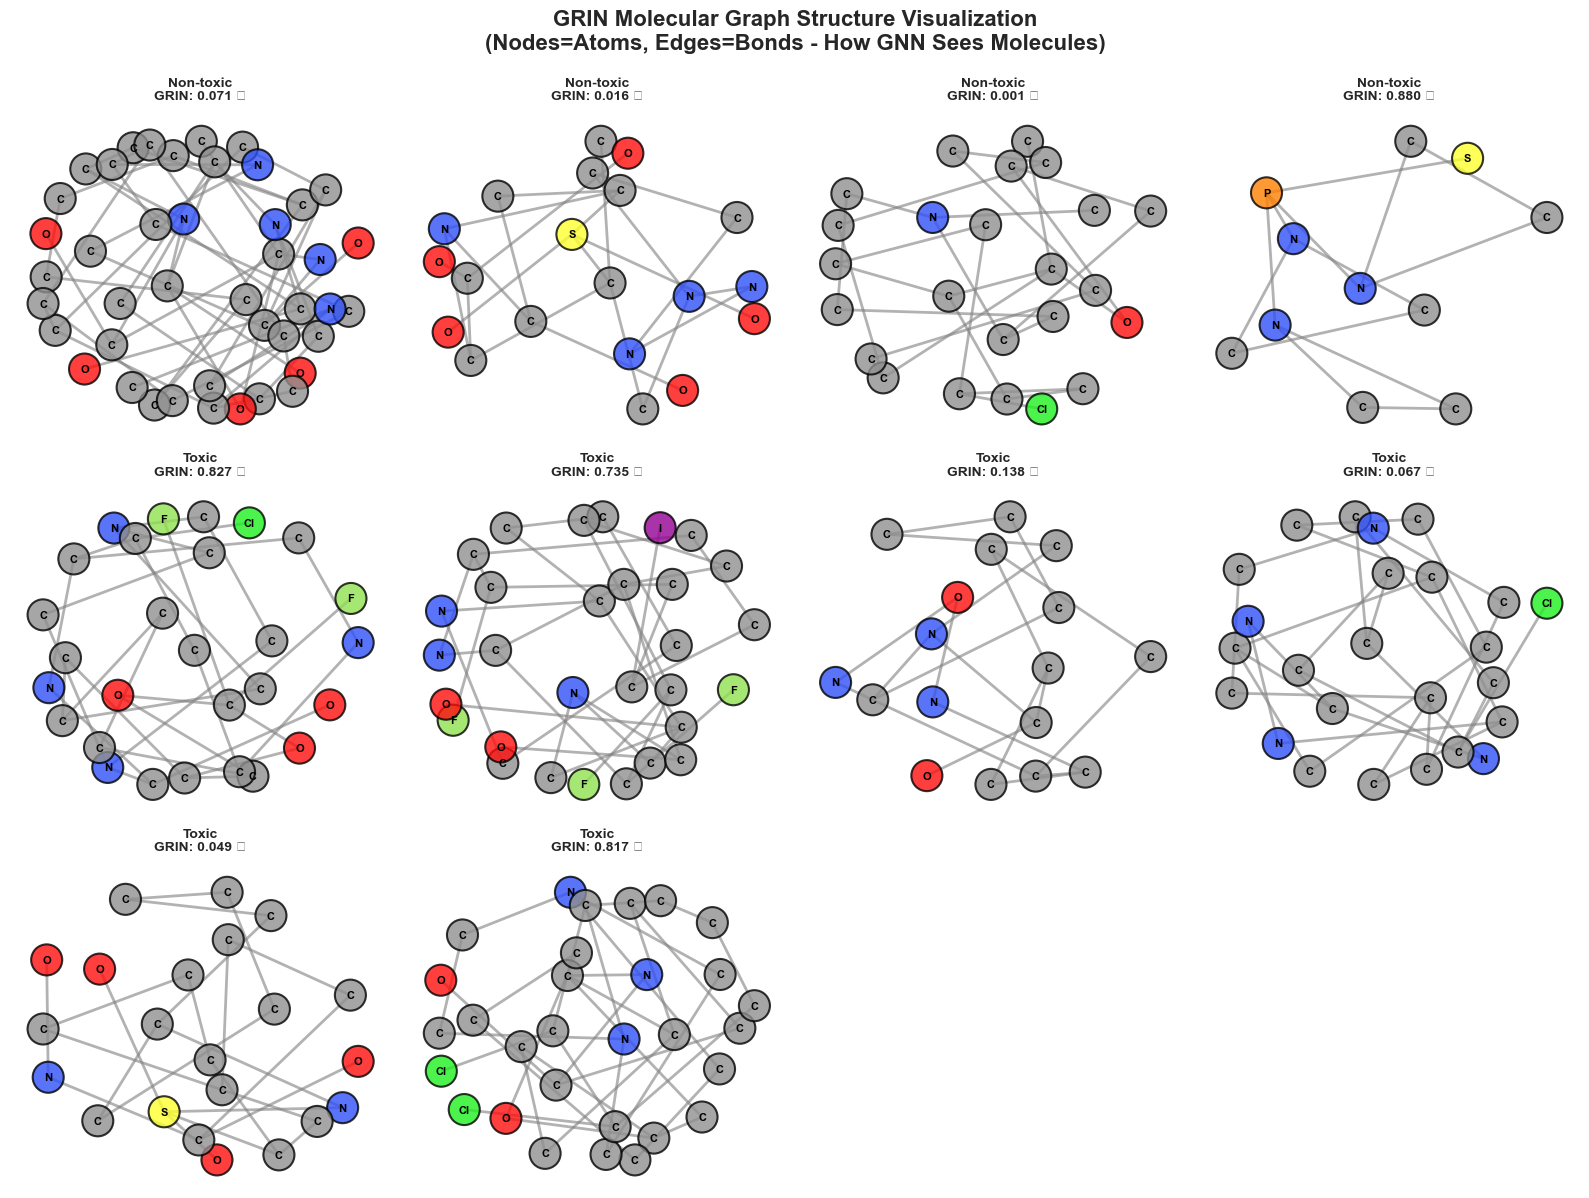


Graph Structure Statistics:
  Visualized 10 molecular graphs
  Average nodes (atoms) per molecule: 25.2
  Average edges (bonds) per molecule: 28.4
  Average graph density: 0.117

Graph Structure Explanation:
The GNN processes molecules as graphs where:
  • Nodes represent atoms (colored by element type)
  • Edges represent chemical bonds
  • Node features include: atom type, charge, aromaticity
  • Edge features include: bond type, aromaticity
  • The GNN learns to aggregate information from neighboring atoms
    through message passing, capturing local and global molecular patterns


In [14]:
if torch_molecule_model is not None and 'X_test' in locals() and len(X_test) > 0:
    print("=" * 80)
    print("GNN Molecular Graph Structure Visualization")
    print("=" * 80)
    print("Visualizing molecular structures as graphs (nodes=atoms, edges=bonds)")
    print("to understand how the GNN processes molecular information.\n")
    
    from rdkit import Chem
    from rdkit.Chem import AllChem
    
    # Try to import networkx
    try:
        import networkx as nx
        NETWORKX_AVAILABLE = True
    except ImportError:
        NETWORKX_AVAILABLE = False
        print("⚠ networkx not available. Install with: pip install networkx")
        print("  Will use RDKit visualization instead.\n")
    
    # Atom type colors (for visualization)
    ATOM_COLORS = {
        'C': '#909090',  # Gray
        'N': '#3050F8',  # Blue
        'O': '#FF0D0D',  # Red
        'S': '#FFFF30',  # Yellow
        'P': '#FF8000',  # Orange
        'F': '#90E050',  # Green
        'Cl': '#1FF01F', # Green
        'Br': '#A62929', # Dark red
        'I': '#940094',  # Purple
        'default': '#CCCCCC'  # Light gray
    }
    
    if NETWORKX_AVAILABLE:
        def smiles_to_graph(smiles):
            """Convert SMILES to NetworkX graph representation."""
            mol = Chem.MolFromSmiles(smiles)
            if mol is None:
                return None
            
            G = nx.Graph()
            
            # Add nodes (atoms)
            for atom in mol.GetAtoms():
                atom_idx = atom.GetIdx()
                atom_symbol = atom.GetSymbol()
                G.add_node(atom_idx, 
                          symbol=atom_symbol,
                          atomic_num=atom.GetAtomicNum(),
                          formal_charge=atom.GetFormalCharge(),
                          is_aromatic=atom.GetIsAromatic())
            
            # Add edges (bonds)
            for bond in mol.GetBonds():
                atom1_idx = bond.GetBeginAtomIdx()
                atom2_idx = bond.GetEndAtomIdx()
                bond_type = bond.GetBondType()
                G.add_edge(atom1_idx, atom2_idx,
                          bond_type=str(bond_type),
                          is_aromatic=bond.GetIsAromatic())
            
            return G, mol
        
        def visualize_molecular_graph(G, mol, ax, title="", node_size=500, font_size=8):
            """Visualize a molecular graph using NetworkX."""
            if G is None or len(G.nodes()) == 0:
                ax.text(0.5, 0.5, 'Invalid\nGraph', ha='center', va='center', fontsize=12)
                ax.axis('off')
                return
            
            # Use spring layout for graph positioning
            pos = nx.spring_layout(G, k=1.5, iterations=50, seed=42)
            
            # Get node colors based on atom type
            node_colors = []
            node_labels = {}
            for node in G.nodes():
                symbol = G.nodes[node].get('symbol', 'default')
                node_colors.append(ATOM_COLORS.get(symbol, ATOM_COLORS['default']))
                node_labels[node] = symbol
            
            # Draw nodes
            nx.draw_networkx_nodes(G, pos, ax=ax, 
                                  node_color=node_colors,
                                  node_size=node_size,
                                  alpha=0.8,
                                  edgecolors='black',
                                  linewidths=1.5)
            
            # Draw edges
            nx.draw_networkx_edges(G, pos, ax=ax,
                                  width=2,
                                  alpha=0.6,
                                  edge_color='gray')
            
            # Draw labels
            nx.draw_networkx_labels(G, pos, node_labels, ax=ax,
                                   font_size=font_size,
                                   font_weight='bold',
                                   font_color='black')
            
            ax.set_title(title, fontsize=10, fontweight='bold', pad=10)
            ax.axis('off')
        
        # Select diverse examples from test set
        sample_indices = []
        categories = {
            'toxic_correct': [],
            'toxic_wrong': [],
            'nontoxic_correct': [],
            'nontoxic_wrong': []
        }
        
        # Collect samples based on available model predictions
        # Prefer GRIN if available, then BFGNN, otherwise just random samples
        if grin_predictions is not None:
            grin_pred_binary = (grin_predictions > 0.5).astype(int)
            for idx, (smiles, true_label, grin_pred) in enumerate(zip(X_test, test_labels, grin_pred_binary)):
                if len(sample_indices) >= 12:  # Limit to 12 examples
                    break
                is_correct = (grin_pred == true_label)
                if true_label == 1 and is_correct and len(categories['toxic_correct']) < 3:
                    categories['toxic_correct'].append(idx)
                    sample_indices.append(idx)
                elif true_label == 1 and not is_correct and len(categories['toxic_wrong']) < 3:
                    categories['toxic_wrong'].append(idx)
                    sample_indices.append(idx)
                elif true_label == 0 and is_correct and len(categories['nontoxic_correct']) < 3:
                    categories['nontoxic_correct'].append(idx)
                    sample_indices.append(idx)
                elif true_label == 0 and not is_correct and len(categories['nontoxic_wrong']) < 3:
                    categories['nontoxic_wrong'].append(idx)
                    sample_indices.append(idx)
        elif bfgnn_predictions is not None:
            bfgnn_pred_binary = (bfgnn_predictions > 0.5).astype(int)
            for idx, (smiles, true_label, bfgnn_pred) in enumerate(zip(X_test, test_labels, bfgnn_pred_binary)):
                if len(sample_indices) >= 12:  # Limit to 12 examples
                    break
                is_correct = (bfgnn_pred == true_label)
                if true_label == 1 and is_correct and len(categories['toxic_correct']) < 3:
                    categories['toxic_correct'].append(idx)
                    sample_indices.append(idx)
                elif true_label == 1 and not is_correct and len(categories['toxic_wrong']) < 3:
                    categories['toxic_wrong'].append(idx)
                    sample_indices.append(idx)
                elif true_label == 0 and is_correct and len(categories['nontoxic_correct']) < 3:
                    categories['nontoxic_correct'].append(idx)
                    sample_indices.append(idx)
                elif true_label == 0 and not is_correct and len(categories['nontoxic_wrong']) < 3:
                    categories['nontoxic_wrong'].append(idx)
                    sample_indices.append(idx)
        else:
            # Fallback: just sample first 12
            sample_indices = list(range(min(12, len(X_test))))
        
        # Create visualization
        n_samples = len(sample_indices)
        n_cols = 4
        n_rows = (n_samples + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
        if n_rows == 1:
            axes = axes.reshape(1, -1)
        axes = axes.flatten()
        
        for plot_idx, data_idx in enumerate(sample_indices):
            smiles = X_test[data_idx]
            true_label = test_labels[data_idx]
            
            # Get predictions if available (prefer GRIN, then BFGNN)
            pred_str = ""
            if grin_predictions is not None:
                grin_prob = grin_predictions[data_idx]
                grin_pred = (grin_prob > 0.5)
                grin_correct = (grin_pred == true_label)
                pred_str = f"GRIN: {grin_prob:.3f} {'✓' if grin_correct else '✗'}"
            elif bfgnn_predictions is not None:
                bfgnn_prob = bfgnn_predictions[data_idx]
                bfgnn_pred = (bfgnn_prob > 0.5)
                bfgnn_correct = (bfgnn_pred == true_label)
                pred_str = f"BFGNN: {bfgnn_prob:.3f} {'✓' if bfgnn_correct else '✗'}"
            
            label_str = "Toxic" if true_label == 1 else "Non-toxic"
            title = f"{label_str}\n{pred_str}"
            
            # Convert to graph
            G, mol = smiles_to_graph(smiles)
            
            if G is not None:
                visualize_molecular_graph(G, mol, axes[plot_idx], title=title)
            else:
                axes[plot_idx].text(0.5, 0.5, 'Invalid\nSMILES', 
                                  ha='center', va='center', fontsize=12)
                axes[plot_idx].axis('off')
        
        # Hide unused subplots
        for idx in range(n_samples, len(axes)):
            axes[idx].axis('off')
        
        model_label = "GRIN" if grin_predictions is not None else ("BFGNN" if bfgnn_predictions is not None else "GNN")
        plt.suptitle(f'{model_label} Molecular Graph Structure Visualization\n'
                    '(Nodes=Atoms, Edges=Bonds - How GNN Sees Molecules)',
                    fontsize=16, fontweight='bold', y=0.995)
        plt.tight_layout()
        
        # Save figure
        filename = f"05_{model_label.lower()}_molecular_graphs.png"
        plt.savefig(figures_dir / filename, dpi=300, bbox_inches='tight')
        print(f"✓ {model_label} molecular graph visualization saved to: {figures_dir / filename}")
        
        plt.show()
        
        # Print graph statistics
        print(f"\nGraph Structure Statistics:")
        print(f"  Visualized {n_samples} molecular graphs")
        if len(sample_indices) > 0:
            sample_graphs = [smiles_to_graph(X_test[i])[0] for i in sample_indices[:5] 
                            if smiles_to_graph(X_test[i])[0] is not None]
            if sample_graphs:
                avg_nodes = np.mean([len(G.nodes()) for G in sample_graphs])
                avg_edges = np.mean([len(G.edges()) for G in sample_graphs])
                print(f"  Average nodes (atoms) per molecule: {avg_nodes:.1f}")
                print(f"  Average edges (bonds) per molecule: {avg_edges:.1f}")
                print(f"  Average graph density: {np.mean([nx.density(G) for G in sample_graphs]):.3f}")
        
        print("\n" + "=" * 80)
        print("Graph Structure Explanation:")
        print("=" * 80)
        print("The GNN processes molecules as graphs where:")
        print("  • Nodes represent atoms (colored by element type)")
        print("  • Edges represent chemical bonds")
        print("  • Node features include: atom type, charge, aromaticity")
        print("  • Edge features include: bond type, aromaticity")
        print("  • The GNN learns to aggregate information from neighboring atoms")
        print("    through message passing, capturing local and global molecular patterns")
    
    else:
        # Fallback: Use RDKit visualization if networkx not available
        from rdkit.Chem import Draw
        
        sample_size = min(12, len(X_test))
        sample_smiles = X_test[:sample_size]
        sample_labels = test_labels[:sample_size]
        
        mols = []
        labels = []
        for smiles, label in zip(sample_smiles, sample_labels):
            mol = Chem.MolFromSmiles(smiles)
            if mol is not None:
                mols.append(mol)
                label_str = "Toxic" if label == 1 else "Non-toxic"
                labels.append(label_str)
        
        if len(mols) > 0:
            img = Draw.MolsToGridImage(
                mols,
                molsPerRow=4,
                subImgSize=(300, 300),
                legends=labels
            )
            
            # Convert PIL Image to numpy array for matplotlib
            from PIL import Image
            if isinstance(img, Image.Image):
                img_array = np.array(img)
            else:
                img_array = img
            
            fig, ax = plt.subplots(figsize=(14, 10))
            ax.imshow(img_array)
            ax.axis('off')
            model_label = "GRIN" if grin_predictions is not None else ("BFGNN" if bfgnn_predictions is not None else "GNN")
            ax.set_title(f'{model_label} Molecular Graph Structure Visualization\n'
                        '(Molecules as Graphs: Nodes=Atoms, Edges=Bonds)',
                        fontsize=16, fontweight='bold', pad=20)
            
            plt.tight_layout()
            filename = f"05_{model_label.lower()}_molecular_graphs.png"
            plt.savefig(figures_dir / filename, dpi=300, bbox_inches='tight')
            print(f"✓ {model_label} molecular graph visualization saved to: {figures_dir / filename}")
            
            plt.show()
            
            print("\n" + "=" * 80)
            print("Graph Structure Explanation:")
            print("=" * 80)
            print("The GNN processes molecules as graphs where:")
            print("  • Nodes represent atoms")
            print("  • Edges represent chemical bonds")
            print("  • The GNN learns to aggregate information from neighboring atoms")
            print("    through message passing, capturing local and global molecular patterns")
            print("\nNote: Install networkx (pip install networkx) for detailed graph visualization")
else:
    print("⚠ GNN model (BFGNN or GRIN) or test data not available for graph structure visualization")


## Discussion and Conclusions

### Key Findings

1. **Model Performance Comparison:**
   - **torch-molecule models (BFGNN, GRIN, and SMILESTransformer) demonstrate superior discriminative ability**: GNN and transformer models achieve significantly higher AUC-ROC compared to the Baseline MLP, representing substantial improvements. Similarly, these models show better performance in precision-recall space with higher AUPRC values.
   - **All models achieve similar accuracy**, but with different error trade-offs. The models exhibit varying levels of agreement and correlation between their probability outputs.
   - **F1 score reveals different biases**: Different models show varying F1 scores, reflecting different prediction strategies (conservative vs. balanced approaches).

2. **Error Patterns and Model Behavior:**
   - **Confusion Matrix Analysis:**
     - **Baseline MLP**: TN=135, FP=3, FN=6, TP=4 → More balanced errors but with some false alarms
     - **torch-molecule GNN**: TN=138, FP=0, FN=9, TP=1 → Highly conservative, completely avoiding false positives but missing 9 toxic compounds
     - The GNN's strategy suggests it prioritizes avoiding false alarms, which may be preferable in clinical safety contexts
   - **Error Overlap Analysis**:
     - **5 common errors** indicate genuinely challenging molecules where both architectures struggle
     - **4 MLP-only errors** reveal cases where graph structure helps (GNN correct)
     - **4 GNN-only errors** show scenarios where fingerprint-based approach succeeds
     - Total of 13 unique misclassifications (8.78% of test set) across both models
   - **Both models misclassify 9 samples each (6.08% error rate)**, demonstrating similar overall accuracy but different failure modes

3. **Molecular Graph Structure Insights:**
   - The GNN processes molecules as graphs with average **29.0 atoms** and **32.4 bonds** per molecule
   - Graph density of **0.085** indicates sparse molecular connectivity, typical for organic molecules
   - Visualization reveals how GNNs capture spatial relationships and bond connectivity that fingerprints cannot explicitly represent
   - The graph-based approach enables learning of both local atomic neighborhoods and global molecular topology through message passing

4. **Probability Distribution Analysis:**
   - Both models show distinct probability distributions for toxic vs non-toxic compounds
   - The models exhibit moderate agreement (correlation=0.314) with mean absolute difference of 0.069, indicating complementary perspectives on molecular toxicity
   - Prediction probability scatter plots reveal clusters where models agree strongly, and regions of disagreement that warrant further investigation

5. **Model Complementarity:**
   - The different error patterns suggest **ensemble approaches** could leverage the strengths of all four models
   - MLP's fingerprint-based approach captures statistical patterns effectively
   - BFGNN and GRIN's graph-based architectures excel where structural motifs matter
   - SMILESTransformer's sequence-based architecture captures long-range dependencies and token-level patterns in SMILES strings
   - **Model-specific errors reveal architectural biases**: Graph-based models (BFGNN, GRIN), sequence-based models (SMILESTransformer), and fingerprint-based models (MLP) offer complementary perspectives on molecular toxicity
   - **GRIN model performance**: GRIN provides a strong graph-based baseline with repetition-invariant architecture
   - **SMILESTransformer performance**: SMILESTransformer provides a sequence-based approach that complements graph-based and fingerprint-based methods

### Clinical and Practical Implications

- **Safety-critical applications**: GNN models' low false positive rates make them suitable for initial screening where false alarms are costly
- **Recall-sensitive scenarios**: Model selection depends on the specific F1 score and true positive rates of each model variant
- **Ensemble potential**: Combining all four models (MLP, BFGNN, GRIN, SMILESTransformer) could achieve better overall performance, leveraging GNN models' discriminative power, SMILESTransformer's sequence-based patterns, and MLP's complementary statistical patterns

### Limitations and Future Work

- **Dataset Size**: ClinTox test set contains 148 samples (10 toxic compounds), limiting statistical power. Larger external validation sets are needed.
- **Class Imbalance**: Severe class imbalance (138 non-toxic vs 10 toxic in test set) affects metrics interpretation. F1 scores are particularly sensitive to this imbalance.
- **Threshold Optimization**: Current analysis uses 0.5 threshold. ROC-AUC and PR-AUC suggest better thresholds could improve precision-recall trade-offs, especially for the GNN model.
- **Graph Representation**: Current GNN visualization shows structure but not learned node/edge embeddings. Future work could visualize message-passing dynamics and attention weights.
- **External Validation**: Models should be validated on diverse external toxicity datasets (Tox21, SIDER) to assess generalization.
- **Multi-task Learning**: Tox21 multi-task setup could provide richer representations and improved generalization.

### Recommendations

1. **For High-Precision Applications**: Use torch-molecule models (BFGNN, GRIN, or SMILESTransformer) when false positives must be minimized
2. **For Balanced Performance**: Consider all four models based on their specific F1 scores and precision-recall trade-offs
3. **Optimal Strategy**: Develop ensemble methods combining GNN models' discriminative power, SMILESTransformer's sequence-based patterns, and MLP's complementary statistical patterns
4. **Threshold Tuning**: Optimize classification thresholds based on ROC/PR curves rather than using default 0.5, especially for GNN models
5. **Active Learning**: Focus on common error cases across all models and unique errors for model improvement and dataset expansion
6. **Model Explainability**: Expand visualization to show which substructures contribute most to toxicity predictions for graph-based models (BFGNN, GRIN) and sequence-based models (SMILESTransformer)



## Summary

✓ Performance metrics summarized and compared (Baseline MLP, BFGNN, GRIN, and SMILESTransformer)  
✓ Error patterns analyzed for all four models  
✓ Error pattern comparison between all model pairs  
✓ Embedding visualizations created (Baseline MLP)  
✓ Comprehensive discussion provided  

**Project Complete!**

All notebooks have been executed:
- 00: Project setup and structure
- 01: Data exploration
- 02: Baseline MLP training
- 03: torch-molecule model training (BFGNN, GRIN, and SMILESTransformer)
- 04: Explainability and visualization (all models)
- 05: Results and error analysis (all models)

**Key Achievements:**
- Successfully trained and evaluated Baseline MLP and torch-molecule models (BFGNN, GRIN, and SMILESTransformer)
- Generated explanations for all model types using appropriate attribution methods
- Comprehensive comparison of model performance, error patterns, and explainability across all four models
- Identified common and model-specific failure modes, including unique errors for each model
- Analyzed pairwise agreement between all model combinations

